# Clasificación y relevancia de variables — Sprint 3

---

## Estructura del notebook

| Sección | Descripción |
|---------|-------------|
| 0 | Importaciones y configuración global |
| 1 | Carga y preparación de datos |
| **EXP 1** | Todas las posiciones — 6 clases |
| **EXP 2** | Posiciones agrupadas (LW+RW→Wing, LB+RB→Lateral) — 4 clases |
| Final | Entrenamiento sobre el dataset completo (train+test) para modelo robusto |

## 0. Importaciones y configuración

In [115]:
#Para solo ejecutar el experimento 2, para ajustar parametros
SOLO_EXP2 = False

import os, math, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score,
    train_test_split, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score,
    f1_score, precision_score, recall_score
)
import xgboost as xgb
from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline

# ── Directorios de salida ────────────────────────────────────
OUT_ROOT = 'position_output'
for d in [OUT_ROOT, f'{OUT_ROOT}/exp1', f'{OUT_ROOT}/exp2', f'{OUT_ROOT}/final']:
    os.makedirs(d, exist_ok=True)

# ── Paleta de colores ────────────────────────────────────────
POS_COLORS = {
    'LW': '#3266ad', 'RW': '#7f77dd',
    'LB': '#d85a30', 'RB': '#ba7517',
    'CB': '#1d9e75',
    'LP': '#d4537e',
    # Grupos (Exp 2)
    'Wing':    '#3266ad',
    'Lateral': '#d85a30',
    'Central': '#1d9e75',
    'Pivote':  '#d4537e',
}

RANDOM_STATE = 42
print('Configuración lista.')

Configuración lista.


## 1. Carga y preparación de datos

In [116]:
ruta_csv = 'EHF2024-W-AGGREGATED.csv'
df_raw = pd.read_csv(ruta_csv)

# ── Variables excluidas
COLS_DROP = ['Unnamed: 0', 'Team', 'No', 'Name',
             'scoring', 'topk', 'top1', 'R7', 'P7',
             'RC', 'Time', '2+2']          # <-- eliminadas según requisito

FEATURE_COLS = [
    '7mPGoals', '7mPMissed',
    '6mCGoals', '6mCMissed',
    'WingGoals', 'WingMissed',
    'BTGoals',  'BTMissed',
    'FBGoals',  'FBMissed',
    'FTOGoals', 'FTOMissed',
    '9mGoals',  '9mMissed',
    '2M', 'AS', 'ST', 'BS', 'TO'
]
TARGET_COL = 'Position'

df_full = df_raw[FEATURE_COLS + [TARGET_COL]].copy()
df_full[TARGET_COL] = df_full[TARGET_COL].astype(str).str.strip()
df_full = df_full.dropna()

print(f'Dataset completo: {df_full.shape[0]} jugadores, {len(FEATURE_COLS)} variables')
print('\nDistribución original de posiciones:')
print(df_full[TARGET_COL].value_counts())

Dataset completo: 414 jugadores, 19 variables

Distribución original de posiciones:
Position
LB    84
LP    64
GK    63
CB    58
LW    51
RB    50
RW    44
Name: count, dtype: int64


---

# ══════════════════════════════════════════
# EXPERIMENTO 1 — Todas las posiciones
# (LW, RW, LB, RB, CB, LP — 6 clases)
# ══════════════════════════════════════════

In [117]:
if not SOLO_EXP2:
    # ── Filtrar porteros ─────────────────────────────────────────
    df_exp1 = df_full[df_full[TARGET_COL] != 'GK'].copy()
    print(f'[EXP 1] Jugadores tras eliminar GK: {len(df_exp1)}')
    print(df_exp1[TARGET_COL].value_counts())
    
    X1 = df_exp1[FEATURE_COLS].values
    y1_raw = df_exp1[TARGET_COL].values
    
    le1 = LabelEncoder()
    y1 = le1.fit_transform(y1_raw)
    print('\nClases EXP 1:', le1.classes_)


[EXP 1] Jugadores tras eliminar GK: 351
Position
LB    84
LP    64
CB    58
LW    51
RB    50
RW    44
Name: count, dtype: int64

Clases EXP 1: ['CB' 'LB' 'LP' 'LW' 'RB' 'RW']


### 1.1 Split 80/20 estratificado + Estandarización z-score

In [118]:
if not SOLO_EXP2:
    X1_train, X1_test, y1_train, y1_test = train_test_split(
        X1, y1, test_size=0.2, random_state=RANDOM_STATE, stratify=y1
    )
    print(f'Train: {X1_train.shape[0]}  |  Test: {X1_test.shape[0]}')


Train: 280  |  Test: 71


### 1.2 Funciones auxiliares

In [119]:
def metrics_table(y_true, y_pred, label_encoder, model_name, cv_mean=None, cv_std=None, train_acc=None):
    """Devuelve DataFrame con métricas globales por modelo."""
    acc   = accuracy_score(y_true, y_pred)
    f1_w  = f1_score(y_true, y_pred, average='weighted')
    f1_m  = f1_score(y_true, y_pred, average='macro')
    prec  = precision_score(y_true, y_pred, average='weighted')
    rec   = recall_score(y_true, y_pred, average='weighted')
    row = {
        'Modelo': model_name,
        'Accuracy': round(acc, 4),
        'F1 (weighted)': round(f1_w, 4),
        'F1 (macro)': round(f1_m, 4),
        'Precision (weighted)': round(prec, 4),
        'Recall (weighted)': round(rec, 4),
    }
    if train_acc is not None:
        row['Train Accuracy'] = round(train_acc, 4)
    if cv_mean is not None:
        row['CV Accuracy (mean)'] = round(cv_mean, 4)
        row['CV Accuracy (std)']  = round(cv_std, 4)
    if train_acc is not None and cv_mean is not None:
        row['Diferencia (Train-CV)'] = round(train_acc - cv_mean, 4)
    return row


def per_class_table(y_true, y_pred, label_encoder, model_name):
    """Tabla de métricas por clase."""
    report = classification_report(
        y_true, y_pred,
        target_names=label_encoder.classes_,
        output_dict=True
    )
    rows = []
    for cls in label_encoder.classes_:
        rows.append({
            'Modelo': model_name,
            'Clase': cls,
            'Precision': round(report[cls]['precision'], 4),
            'Recall':    round(report[cls]['recall'],    4),
            'F1-score':  round(report[cls]['f1-score'],  4),
        })
    return rows


def save_confusion_matrix(y_true, y_pred, label_encoder, model_name, filepath):
    """Guarda la matriz de confusión como imagen PNG."""
    cm   = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(cm, display_labels=label_encoder.classes_)
    disp.plot(ax=ax, colorbar=True, cmap='Blues')
    acc = accuracy_score(y_true, y_pred)
    ax.set_title(f'{model_name}  (acc={acc:.3f})', fontsize=13, fontweight='bold')
    plt.tight_layout()
    fig.savefig(filepath, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Guardada: {filepath}')


cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

### 1.3 Random Forest + GridSearchCV

In [120]:
param_grid_rf = {
    'n_estimators':      [50, 100, 200, 300, 350, 400],
    'max_depth':         [None, 3, 7, 10, 20],
    'min_samples_leaf':  [1, 2, 3, 5],
    'min_samples_split': [2, 3, 4, 5],
    'max_features':      [None, 'sqrt', 'log2']
}

if not SOLO_EXP2:
    pipe_rf1 = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
    ])
    param_grid_rf1_pipe = {f'model__{k}': v for k, v in param_grid_rf.items()}
    gs_rf1 = GridSearchCV(pipe_rf1, param_grid_rf1_pipe, cv=cv5, scoring='accuracy', n_jobs=-1, verbose=0)
    gs_rf1.fit(X1_train, y1_train)
    rf1 = gs_rf1.best_estimator_

    print(f'[EXP1 RF] Mejores hiperparámetros: {gs_rf1.best_params_}')
    print(f'[EXP1 RF] CV accuracy (best):      {gs_rf1.best_score_:.4f}')

    y1_pred_rf    = rf1.predict(X1_test)
    train_acc_rf1 = accuracy_score(y1_train, rf1.predict(X1_train))
    cv_rf1        = gs_rf1.best_score_

    print(f'[EXP1 RF] Train accuracy: {train_acc_rf1:.4f}')
    print(f'[EXP1 RF] Test accuracy:  {accuracy_score(y1_test, y1_pred_rf):.4f}')
    print(f'[EXP1 RF] Diferencia Train-Test: {train_acc_rf1 - accuracy_score(y1_test, y1_pred_rf):.4f}')
    print(classification_report(y1_test, y1_pred_rf, target_names=le1.classes_))


[EXP1 RF] Mejores hiperparámetros: {'model__max_depth': 10, 'model__max_features': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 50}
[EXP1 RF] CV accuracy (best):      0.5464
[EXP1 RF] Train accuracy: 0.9750
[EXP1 RF] Test accuracy:  0.5915
[EXP1 RF] Diferencia Train-Test: 0.3835
              precision    recall  f1-score   support

          CB       0.56      0.42      0.48        12
          LB       0.54      0.76      0.63        17
          LP       0.63      0.92      0.75        13
          LW       0.64      0.70      0.67        10
          RB       0.00      0.00      0.00        10
          RW       0.71      0.56      0.62         9

    accuracy                           0.59        71
   macro avg       0.51      0.56      0.53        71
weighted avg       0.52      0.59      0.54        71



### 1.4 XGBoost + GridSearchCV

In [121]:
param_grid_xgb = {
    'n_estimators':      [10, 15, 25, 75, 100, 150, 200],
    'max_depth':         [2, 5, 6, 10, 15, 20],
    'colsample_bytree':  [0.4, 0.7, 0.9],
    'subsample':         [0.4, 0.7, 0.9],
    'reg_alpha':         [0.4, 0.7, 0.9],
    'min_child_weight':  [1, 2, 3, 5],
    'learning_rate':     [0.1, 0.3, 0.5]
}

if not SOLO_EXP2:
    pipe_xgb1 = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  xgb.XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1, verbosity=0))
    ])
    param_grid_xgb1_pipe = {f'model__{k}': v for k, v in param_grid_xgb.items()}
    gs_xgb1 = GridSearchCV(pipe_xgb1, param_grid_xgb1_pipe, cv=cv5, scoring='accuracy', n_jobs=-1, verbose=0)
    gs_xgb1.fit(X1_train, y1_train)
    xgb1 = gs_xgb1.best_estimator_

    print(f'[EXP1 XGB] Mejores hiperparámetros: {gs_xgb1.best_params_}')
    print(f'[EXP1 XGB] CV accuracy (best):      {gs_xgb1.best_score_:.4f}')

    y1_pred_xgb    = xgb1.predict(X1_test)
    train_acc_xgb1 = accuracy_score(y1_train, xgb1.predict(X1_train))
    cv_xgb1        = gs_xgb1.best_score_

    print(f'[EXP1 XGB] Train accuracy: {train_acc_xgb1:.4f}')
    print(f'[EXP1 XGB] Test accuracy:  {accuracy_score(y1_test, y1_pred_xgb):.4f}')
    print(f'[EXP1 XGB] Diferencia Train-Test: {train_acc_xgb1 - accuracy_score(y1_test, y1_pred_xgb):.4f}')
    print(classification_report(y1_test, y1_pred_xgb, target_names=le1.classes_))


[EXP1 XGB] Mejores hiperparámetros: {'model__colsample_bytree': 0.9, 'model__learning_rate': 0.5, 'model__max_depth': 5, 'model__min_child_weight': 2, 'model__n_estimators': 200, 'model__reg_alpha': 0.7, 'model__subsample': 0.7}
[EXP1 XGB] CV accuracy (best):      0.5786
[EXP1 XGB] Train accuracy: 0.9750
[EXP1 XGB] Test accuracy:  0.6338
[EXP1 XGB] Diferencia Train-Test: 0.3412
              precision    recall  f1-score   support

          CB       0.58      0.58      0.58        12
          LB       0.60      0.71      0.65        17
          LP       0.75      0.92      0.83        13
          LW       0.67      0.80      0.73        10
          RB       0.00      0.00      0.00        10
          RW       0.86      0.67      0.75         9

    accuracy                           0.63        71
   macro avg       0.58      0.61      0.59        71
weighted avg       0.58      0.63      0.60        71



### 1.5 SVM + GridSearchCV

In [122]:
param_grid_svm = {
    'C':      [0.001, 0.01, 0.1, 0.5, 1.0, 1.5, 2.0, 5.0, 10.0, 50.0, 100.0],
    'gamma':  ['scale', 'auto', 0.001, 0.01, 0.1, 1.0],
    'kernel': ['rbf', 'linear', 'sigmoid', 'poly'],
}

if not SOLO_EXP2:
    pipe_svm1 = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  SVC(class_weight='balanced', random_state=RANDOM_STATE, probability=True))
    ])
    param_grid_svm1_pipe = {f'model__{k}': v for k, v in param_grid_svm.items()}
    gs_svm1 = GridSearchCV(pipe_svm1, param_grid_svm1_pipe, cv=cv5, scoring='accuracy', n_jobs=-1, verbose=0)
    gs_svm1.fit(X1_train, y1_train)
    svm1 = gs_svm1.best_estimator_

    print(f'[EXP1 SVM] Mejores hiperparámetros: {gs_svm1.best_params_}')
    print(f'[EXP1 SVM] CV accuracy (best):      {gs_svm1.best_score_:.4f}')

    y1_pred_svm    = svm1.predict(X1_test)
    train_acc_svm1 = accuracy_score(y1_train, svm1.predict(X1_train))
    cv_svm1        = cross_val_score(svm1, X1_train, y1_train, cv=cv5, scoring='accuracy')

    print(f'[EXP1 SVM] Train accuracy: {train_acc_svm1:.4f}')
    print(f'[EXP1 SVM] Test accuracy:  {accuracy_score(y1_test, y1_pred_svm):.4f}')
    print(f'[EXP1 SVM] Diferencia Train-Test: {train_acc_svm1 - accuracy_score(y1_test, y1_pred_svm):.4f}')
    print(classification_report(y1_test, y1_pred_svm, target_names=le1.classes_))


[EXP1 SVM] Mejores hiperparámetros: {'model__C': 100.0, 'model__gamma': 0.01, 'model__kernel': 'sigmoid'}
[EXP1 SVM] CV accuracy (best):      0.5107
[EXP1 SVM] Train accuracy: 0.5857
[EXP1 SVM] Test accuracy:  0.5352
[EXP1 SVM] Diferencia Train-Test: 0.0505
              precision    recall  f1-score   support

          CB       0.64      0.58      0.61        12
          LB       0.67      0.47      0.55        17
          LP       0.48      0.85      0.61        13
          LW       0.62      0.50      0.56        10
          RB       0.25      0.20      0.22        10
          RW       0.56      0.56      0.56         9

    accuracy                           0.54        71
   macro avg       0.54      0.53      0.52        71
weighted avg       0.55      0.54      0.53        71



### 1.6 Red Neuronal (MLP) + GridSearchCV

In [123]:
param_grid_mlp = {
    'hidden_layer_sizes': [
        (32,),
        (64,),
        (32, 16),
        (64, 32),
        (128, 64),
        (256, 128),
        (128, 64, 32),
        (256, 128, 64),
        (512, 256, 128),
        (512, 256, 128, 64),
        (512, 256, 128, 64, 32),
        (1024, 512, 256, 128, 64, 32)
    ],
    'activation':         ['relu', 'tanh'],
    'alpha':              [1e-4, 5e-4, 1e-3, 5e-3, 1e-2],
    'learning_rate_init': [0.0001, 0.0005, 0.001, 0.005],
    'learning_rate':      ['adaptive', 'constant'],
}

if not SOLO_EXP2:
    pipe_mlp1 = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  MLPClassifier(max_iter=500, early_stopping=True, random_state=RANDOM_STATE))
    ])
    param_grid_mlp1_pipe = {f'model__{k}': v for k, v in param_grid_mlp.items()}
    gs_mlp1 = GridSearchCV(pipe_mlp1, param_grid_mlp1_pipe, cv=cv5, scoring='accuracy', n_jobs=-1, verbose=0)
    gs_mlp1.fit(X1_train, y1_train)
    mlp1 = gs_mlp1.best_estimator_

    print(f'[EXP1 MLP] Mejores hiperparámetros: {gs_mlp1.best_params_}')
    print(f'[EXP1 MLP] CV accuracy (best):      {gs_mlp1.best_score_:.4f}')

    y1_pred_mlp    = mlp1.predict(X1_test)
    train_acc_mlp1 = accuracy_score(y1_train, mlp1.predict(X1_train))
    cv_mlp1        = cross_val_score(mlp1, X1_train, y1_train, cv=cv5, scoring='accuracy')

    print(f'[EXP1 MLP] Train accuracy: {train_acc_mlp1:.4f}')
    print(f'[EXP1 MLP] Test accuracy:  {accuracy_score(y1_test, y1_pred_mlp):.4f}')
    print(f'[EXP1 MLP] Diferencia Train-Test: {train_acc_mlp1 - accuracy_score(y1_test, y1_pred_mlp):.4f}')
    print(classification_report(y1_test, y1_pred_mlp, target_names=le1.classes_))


[EXP1 MLP] Mejores hiperparámetros: {'model__activation': 'relu', 'model__alpha': 0.0005, 'model__hidden_layer_sizes': (512, 256, 128, 64, 32), 'model__learning_rate': 'adaptive', 'model__learning_rate_init': 0.0005}
[EXP1 MLP] CV accuracy (best):      0.4893
[EXP1 MLP] Train accuracy: 0.6679
[EXP1 MLP] Test accuracy:  0.5211
[EXP1 MLP] Diferencia Train-Test: 0.1467
              precision    recall  f1-score   support

          CB       0.50      0.50      0.50        12
          LB       0.67      0.71      0.69        17
          LP       0.59      1.00      0.74        13
          LW       0.36      0.50      0.42        10
          RB       0.00      0.00      0.00        10
          RW       0.20      0.11      0.14         9

    accuracy                           0.52        71
   macro avg       0.39      0.47      0.41        71
weighted avg       0.43      0.52      0.46        71



### 1.7 Matrices de confusión (imágenes)

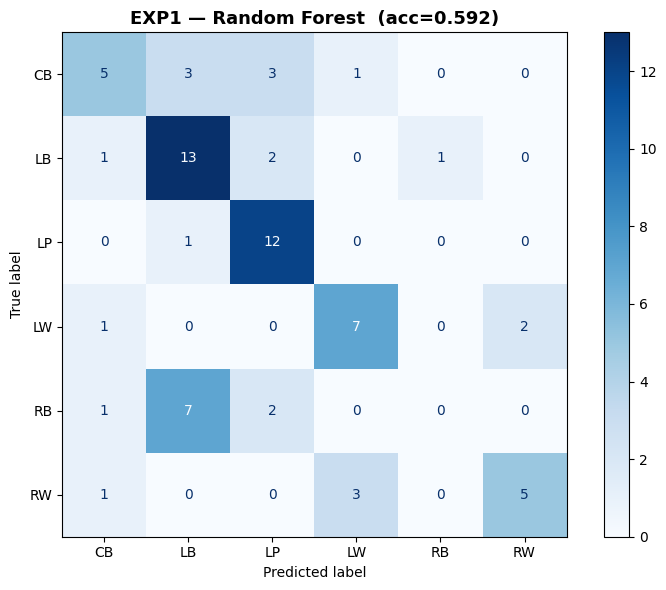

Guardada: position_output/exp1/cm_random_forest.png


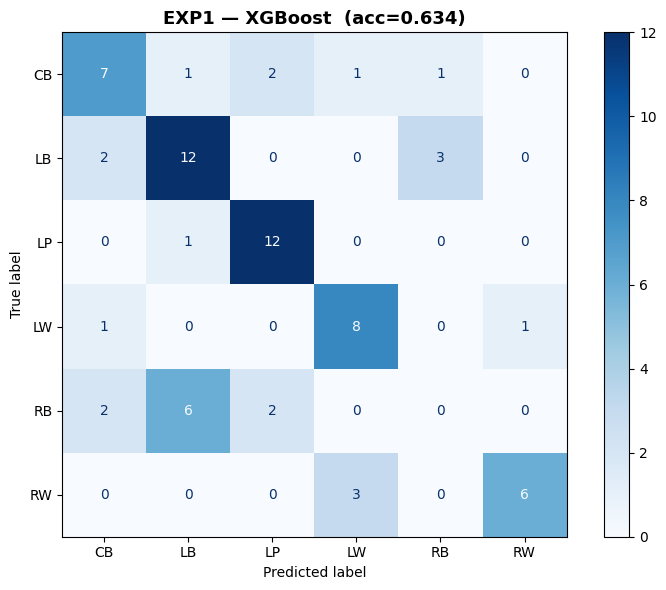

Guardada: position_output/exp1/cm_xgboost.png


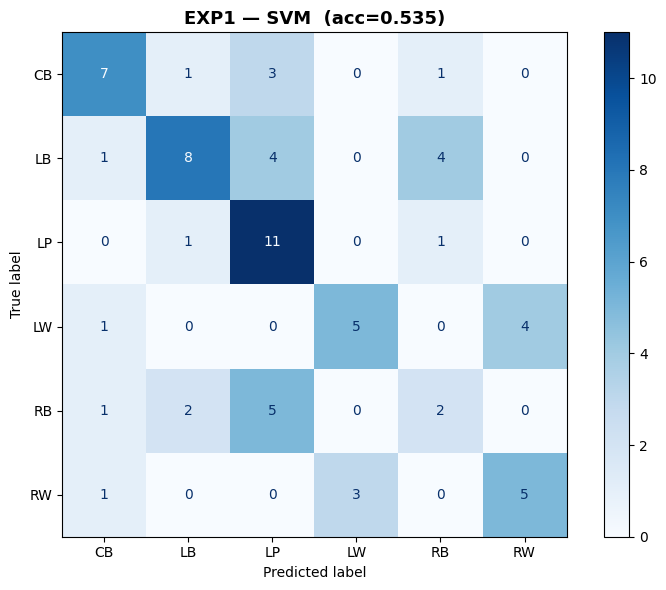

Guardada: position_output/exp1/cm_svm.png


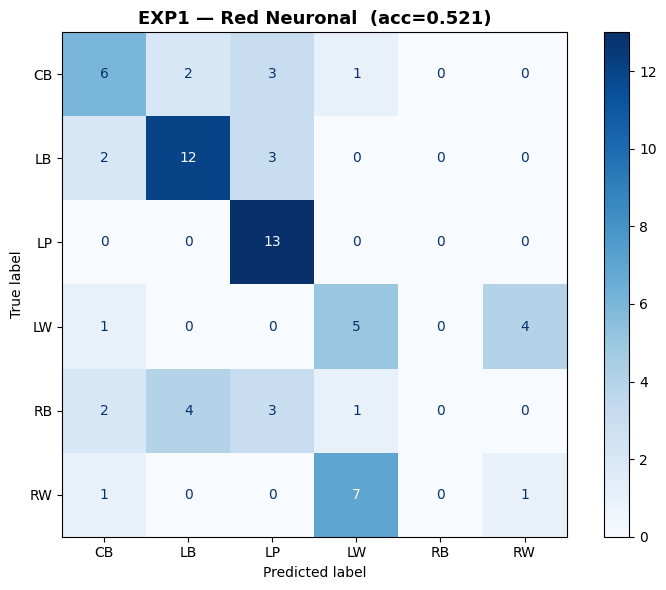

Guardada: position_output/exp1/cm_red_neuronal.png


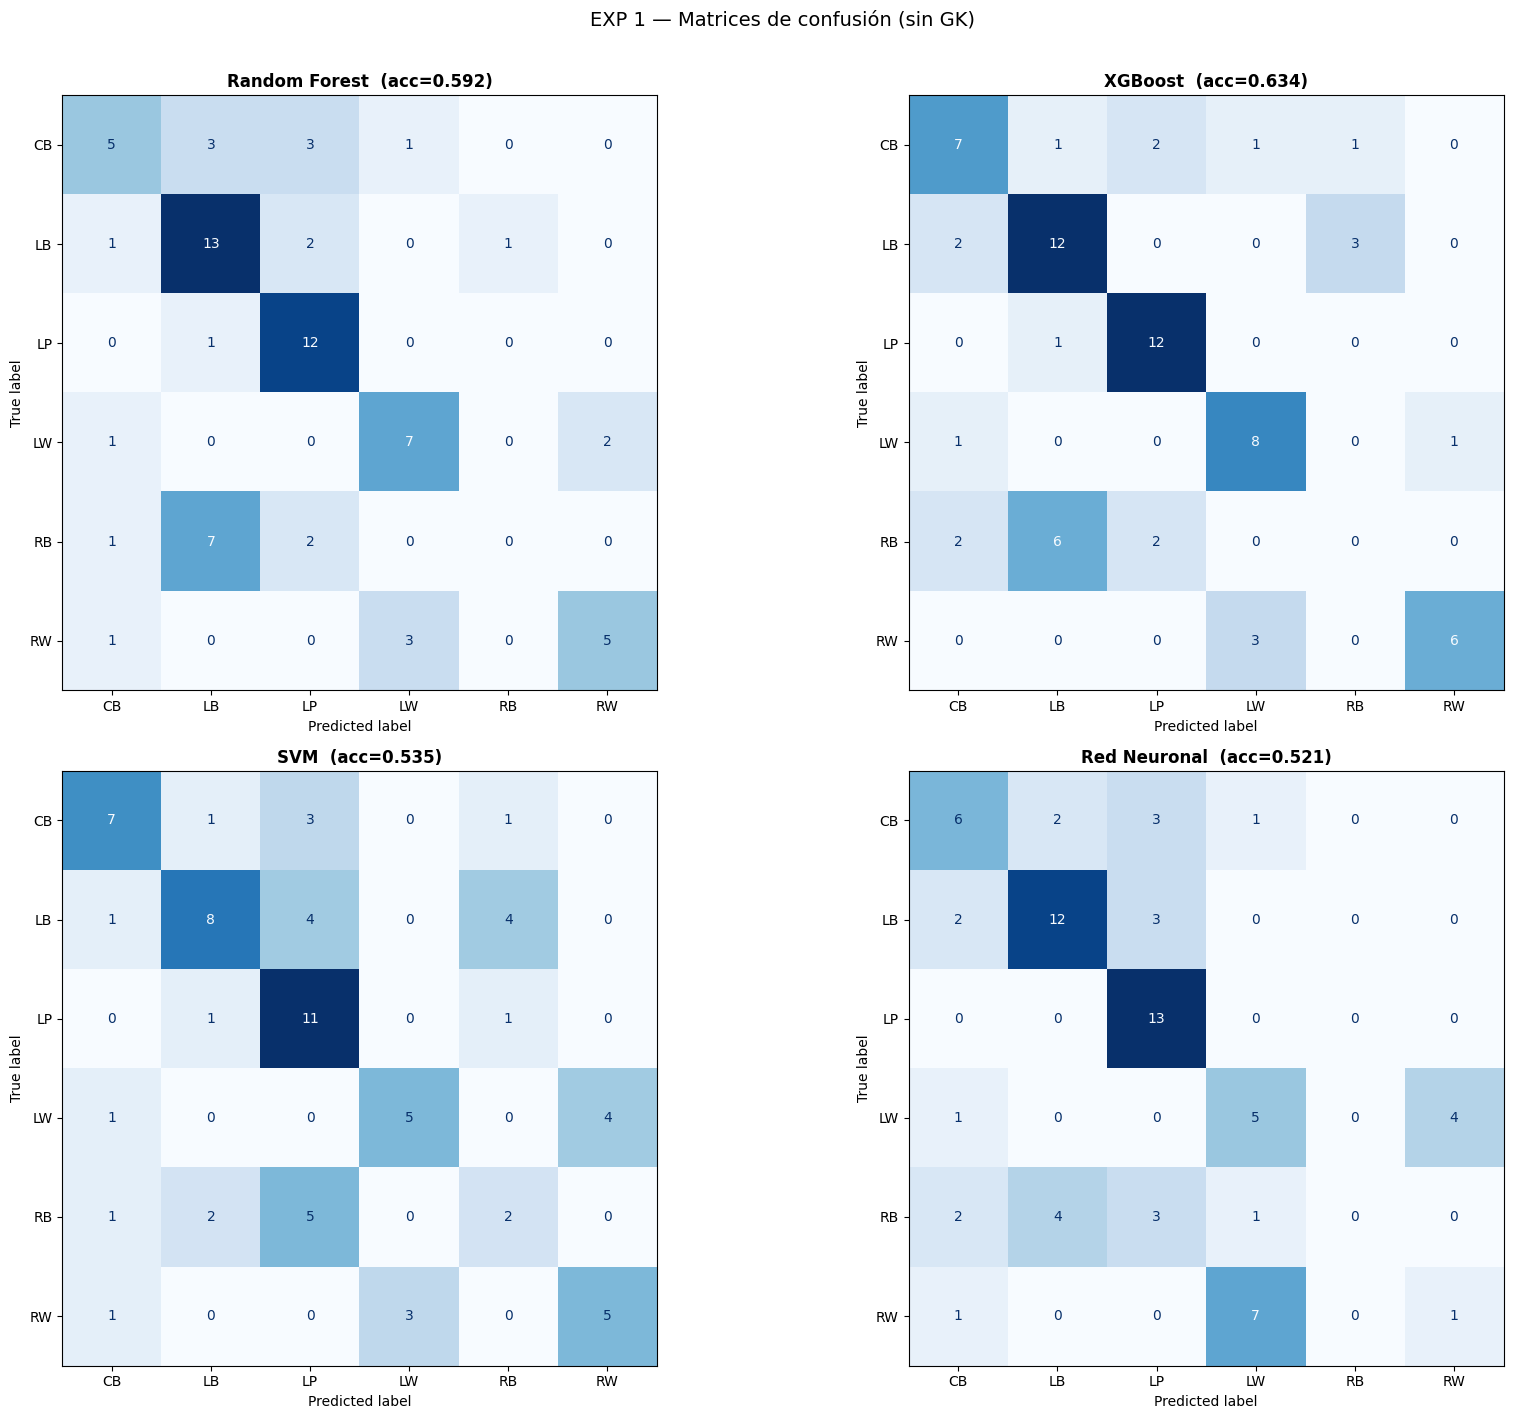

Guardada figura combinada: position_output/exp1/confusion_matrices_all.png


In [124]:
if not SOLO_EXP2:
    models_exp1 = [
        ('Random Forest', y1_pred_rf),
        ('XGBoost',       y1_pred_xgb),
        ('SVM',           y1_pred_svm),
        ('Red Neuronal',  y1_pred_mlp),
    ]
    
    for name, preds in models_exp1:
        path = f"{OUT_ROOT}/exp1/cm_{name.replace(' ','_').lower()}.png"
        save_confusion_matrix(y1_test, preds, le1, f'EXP1 — {name}', path)
    
    # Figura combinada de las 4 matrices
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    axes = axes.flatten()
    for ax, (name, preds) in zip(axes, models_exp1):
        cm = confusion_matrix(y1_test, preds)
        disp = ConfusionMatrixDisplay(cm, display_labels=le1.classes_)
        disp.plot(ax=ax, colorbar=False, cmap='Blues')
        acc = accuracy_score(y1_test, preds)
        ax.set_title(f'{name}  (acc={acc:.3f})', fontsize=12, fontweight='bold')
    plt.suptitle('EXP 1 — Matrices de confusión (sin GK)', fontsize=14, y=1.01)
    plt.tight_layout()
    fig.savefig(f'{OUT_ROOT}/exp1/confusion_matrices_all.png', dpi=130, bbox_inches='tight')
    plt.show()
    print(f"Guardada figura combinada: {OUT_ROOT}/exp1/confusion_matrices_all.png")


### 1.8 Tabla de métricas — EXP 1

In [125]:
if not SOLO_EXP2:
    train_accs1 = [train_acc_rf1, train_acc_xgb1, train_acc_svm1, train_acc_mlp1]
    cvs1 = [
        (cv_rf1.mean(),  cv_rf1.std()),
        (cv_xgb1.mean(), cv_xgb1.std()),
        (cv_svm1.mean(), cv_svm1.std()),
        (cv_mlp1.mean(), cv_mlp1.std()),
    ]
    
    rows_exp1 = []
    for (name, preds), (cv_m, cv_s), tr_acc in zip(models_exp1, cvs1, train_accs1):
        rows_exp1.append(metrics_table(y1_test, preds, le1, name, cv_m, cv_s, tr_acc))
    
    df_metrics_exp1 = pd.DataFrame(rows_exp1).set_index('Modelo')
    # Reordenar columnas para lectura intuitiva
    col_order1 = ['Train Accuracy', 'CV Accuracy (mean)', 'CV Accuracy (std)',
                  'Accuracy', 'Diferencia (Train-CV)', 'F1 (weighted)', 'F1 (macro)',
                  'Precision (weighted)', 'Recall (weighted)']
    df_metrics_exp1 = df_metrics_exp1[[c for c in col_order1 if c in df_metrics_exp1.columns]]
    print('=== EXP 1 — Métricas globales (con Comprobación de sobreajuste) ===')
    display(df_metrics_exp1.style.background_gradient(subset=['Diferencia (Train-CV)'], cmap='RdYlGn_r'))
    df_metrics_exp1.to_csv(f'{OUT_ROOT}/exp1/metrics_global.csv')
    
    # Tabla por clase
    rows_class_exp1 = []
    for name, preds in models_exp1:
        rows_class_exp1.extend(per_class_table(y1_test, preds, le1, name))
    df_class_exp1 = pd.DataFrame(rows_class_exp1)
    print('\n=== EXP 1 — Métricas por clase ===')
    display(df_class_exp1)
    df_class_exp1.to_csv(f'{OUT_ROOT}/exp1/metrics_per_class.csv', index=False)


=== EXP 1 — Métricas globales (con Comprobación de sobreajuste) ===


,Train Accuracy,CV Accuracy (mean),CV Accuracy (std),Accuracy,Diferencia (Train-CV),F1 (weighted),F1 (macro),Precision (weighted),Recall (weighted)
Modelo,,,,,,,,,
Random Forest,0.975000,0.546400,0.000000,0.591500,0.428600,0.542800,0.525300,0.519400,0.591500
XGBoost,0.975000,0.578600,0.000000,0.633800,0.396400,0.602900,0.589500,0.582100,0.633800
SVM,0.585700,0.510700,0.047400,0.535200,0.075000,0.526800,0.517500,0.548400,0.535200
Red Neuronal,0.667900,0.489300,0.064500,0.521100,0.178600,0.461500,0.414700,0.428000,0.521100



=== EXP 1 — Métricas por clase ===


,Modelo,Clase,Precision,Recall,F1-score
0,Random Forest,CB,0.5556,0.4167,0.4762
1,Random Forest,LB,0.5417,0.7647,0.6341
2,Random Forest,LP,0.6316,0.9231,0.7500
3,Random Forest,LW,0.6364,0.7000,0.6667
4,Random Forest,RB,0.0000,0.0000,0.0000
5,Random Forest,RW,0.7143,0.5556,0.6250
6,XGBoost,CB,0.5833,0.5833,0.5833
7,XGBoost,LB,0.6000,0.7059,0.6486
8,XGBoost,LP,0.7500,0.9231,0.8276
9,XGBoost,LW,0.6667,0.8000,0.7273


### 1.10 Comprobacion de sobreajuste — EXP 1

Comparamos **Train Accuracy**, **CV Accuracy (5-fold sobre train)** y **Test Accuracy** para detectar sobreajuste:

Se añaden también las **curvas de aprendizaje** para ver cómo evoluciona la brecha al variar el tamaño de entrenamiento.

=== EXP 1 — Comprobación de sobreajuste ===


,Train Accuracy,CV Accuracy (mean),CV Std (±),Test Accuracy,Diferencia Train-CV,Diferencia Train-Test
Modelo,,,,,,
Random Forest,0.975000,0.546400,0.000000,0.591500,0.428600,0.383500
XGBoost,0.975000,0.578600,0.000000,0.633800,0.396400,0.341200
SVM,0.585700,0.510700,0.047400,0.535200,0.075000,0.050500
Red Neuronal,0.667900,0.489300,0.064500,0.521100,0.178600,0.146700


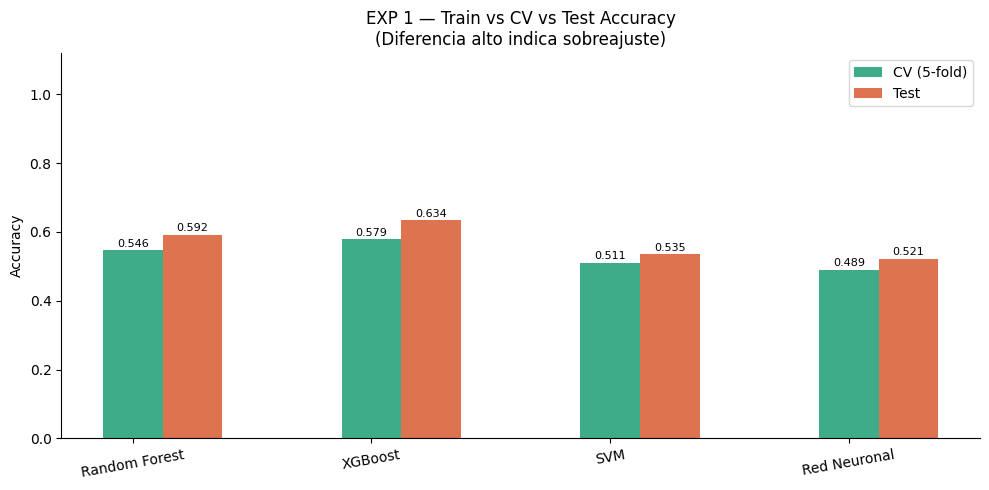

Guardada: position_output/exp1/overfit_train_cv_test.png


In [126]:
if not SOLO_EXP2:
    # ── Tabla resumen Train / CV / Test ─────────────────────────
    models_exp1_dict = {
        'Random Forest': (rf1,  train_acc_rf1,  cv_rf1,  y1_pred_rf),
        'XGBoost':       (xgb1, train_acc_xgb1, cv_xgb1, y1_pred_xgb),
        'SVM':           (svm1, train_acc_svm1, cv_svm1, y1_pred_svm),
        'Red Neuronal':  (mlp1, train_acc_mlp1, cv_mlp1, y1_pred_mlp),
    }
    
    overfit_rows1 = []
    for mname, (model, tr_acc, cv_scores, preds) in models_exp1_dict.items():
        test_acc = accuracy_score(y1_test, preds)
        overfit_rows1.append({
            'Modelo':            mname,
            'Train Accuracy':    round(tr_acc, 4),
            'CV Accuracy (mean)':round(cv_scores.mean(), 4),
            'CV Std (±)':        round(cv_scores.std(), 4),
            'Test Accuracy':     round(test_acc, 4),
            'Diferencia Train-CV':      round(tr_acc - cv_scores.mean(), 4),
            'Diferencia Train-Test':    round(tr_acc - test_acc, 4),
        })
    
    df_overfit1 = pd.DataFrame(overfit_rows1).set_index('Modelo')
    print('=== EXP 1 — Comprobación de sobreajuste ===')
    display(df_overfit1.style.background_gradient(subset=['Diferencia Train-CV', 'Diferencia Train-Test'],
                                                   cmap='RdYlGn_r'))
    df_overfit1.to_csv(f'{OUT_ROOT}/exp1/overfit_diagnosis.csv')
    
    # ── Gráfico: Train vs CV vs Test Accuracy ───────────────────
    fig, ax = plt.subplots(figsize=(10, 5))
    x      = np.arange(len(overfit_rows1))
    width  = 0.25
    names  = [r['Modelo'] for r in overfit_rows1]
    tr_vals  = [r['Train Accuracy']     for r in overfit_rows1]
    cv_vals  = [r['CV Accuracy (mean)'] for r in overfit_rows1]
    te_vals  = [r['Test Accuracy']      for r in overfit_rows1]
    
    b2 = ax.bar(x, cv_vals, width, label='CV (5-fold)',   color='#1d9e75', alpha=0.85)
    b3 = ax.bar(x + width, te_vals, width, label='Test',          color='#d85a30', alpha=0.85)
    
    for bars in [b2, b3]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=10)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel('Accuracy')
    ax.set_title('EXP 1 — Train vs CV vs Test Accuracy\n(Diferencia alto indica sobreajuste)', fontsize=12)
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    fig.savefig(f'{OUT_ROOT}/exp1/overfit_train_cv_test.png', dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Guardada: {OUT_ROOT}/exp1/overfit_train_cv_test.png')


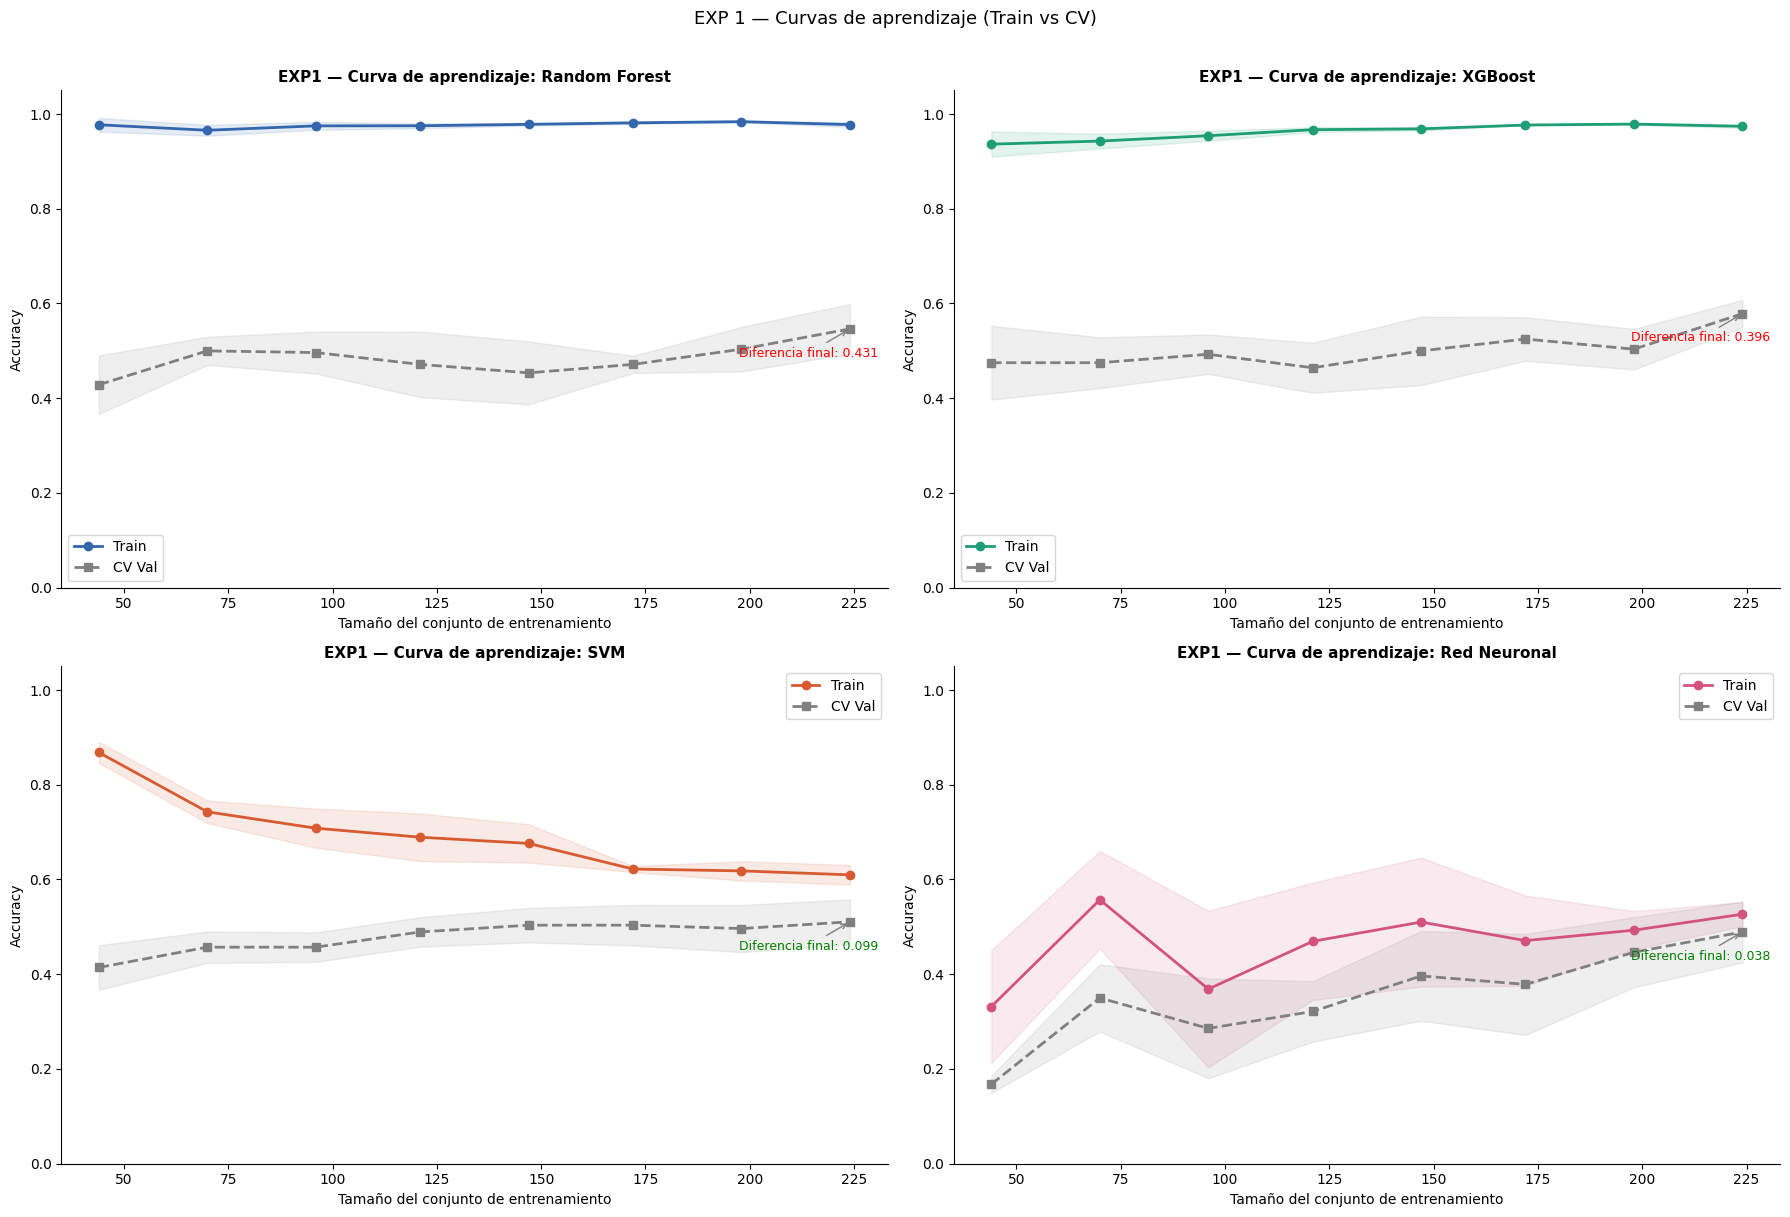

Guardada: position_output/exp1/learning_curves.png


In [127]:
if not SOLO_EXP2:
    # ── Curvas de aprendizaje — EXP 1 ───────────────────────────
    lc_models1 = [
        ('Random Forest', rf1,  '#3266ad'),
        ('XGBoost',       xgb1, '#1d9e75'),
        ('SVM',           svm1, '#d85a30'),
        ('Red Neuronal',  mlp1, '#d4537e'),
    ]
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    axes = axes.flatten()
    
    for ax, (mname, model, color) in zip(axes, lc_models1):
        train_sizes, train_scores, val_scores = learning_curve(
            model, X1_train, y1_train,
            cv=cv5, scoring='accuracy',
            train_sizes=np.linspace(0.2, 1.0, 8),
            n_jobs=-1
        )
        tr_mean  = train_scores.mean(axis=1)
        tr_std   = train_scores.std(axis=1)
        val_mean = val_scores.mean(axis=1)
        val_std  = val_scores.std(axis=1)
    
        ax.plot(train_sizes, tr_mean,  'o-', color=color,   label='Train',   linewidth=2)
        ax.plot(train_sizes, val_mean, 's--', color='gray', label='CV Val',  linewidth=2)
        ax.fill_between(train_sizes, tr_mean - tr_std,  tr_mean + tr_std,  alpha=0.12, color=color)
        ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.12, color='gray')
        ax.set_xlabel('Tamaño del conjunto de entrenamiento')
        ax.set_ylabel('Accuracy')
        ax.set_title(f'EXP1 — Curva de aprendizaje: {mname}', fontsize=11, fontweight='bold')
        ax.legend()
        ax.set_ylim(0, 1.05)
        ax.spines[['top', 'right']].set_visible(False)
        # Anotar Diferencia final
        Diferencia = tr_mean[-1] - val_mean[-1]
        ax.annotate(f'Diferencia final: {Diferencia:.3f}',
                    xy=(train_sizes[-1], val_mean[-1]),
                    xytext=(-80, -20), textcoords='offset points',
                    fontsize=9, color='red' if Diferencia > 0.10 else 'green',
                    arrowprops=dict(arrowstyle='->', color='gray'))
    
    plt.suptitle('EXP 1 — Curvas de aprendizaje (Train vs CV)', fontsize=13, y=1.01)
    plt.tight_layout()
    fig.savefig(f'{OUT_ROOT}/exp1/learning_curves.png', dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Guardada: {OUT_ROOT}/exp1/learning_curves.png')


### 1.9 Análisis SHAP — EXP 1 (mejor modelo)

Mejor modelo EXP1: XGBoost  (0.6338)


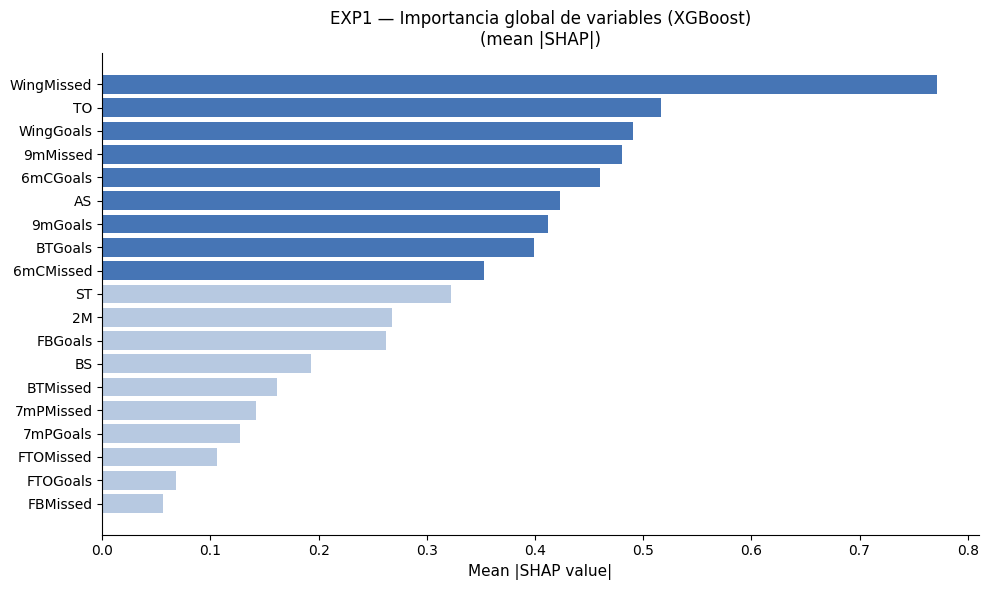


Top 10 variables más importantes (EXP1):


,mean_abs_shap
WingMissed,0.7716
TO,0.5162
WingGoals,0.4905
9mMissed,0.4800
6mCGoals,0.4602
AS,0.4227
9mGoals,0.4121
BTGoals,0.3994
6mCMissed,0.3525
ST,0.3222


In [128]:
if not SOLO_EXP2:
    accs1 = {name: accuracy_score(y1_test, p) for name, p in models_exp1}
    best_name1 = max(accs1, key=accs1.get)
    best_model1_map = {
        'Random Forest': rf1,
        'XGBoost':       xgb1,
    }
    print(f'Mejor modelo EXP1: {best_name1}  ({accs1[best_name1]:.4f})')

    shap_model1_name = best_name1 if best_name1 in best_model1_map else 'XGBoost'
    shap_pipe1  = best_model1_map[shap_model1_name]
    shap_model1 = shap_pipe1.named_steps['model']
    X1_all_sc   = shap_pipe1.named_steps['scaler'].transform(X1)

    explainer1 = shap.TreeExplainer(shap_model1)
    shap_vals1 = explainer1.shap_values(X1_all_sc)

    if isinstance(shap_vals1, list):
        global_shap1 = np.mean([np.abs(sv).mean(axis=0) for sv in shap_vals1], axis=0)
    else:
        global_shap1 = np.abs(shap_vals1).mean(axis=(0, 2)) if shap_vals1.ndim == 3 else np.abs(shap_vals1).mean(axis=0)

    shap_imp1 = pd.Series(global_shap1, index=FEATURE_COLS).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    colors_bar = ['#3266ad' if v > shap_imp1.median() else '#b0c4de' for v in shap_imp1.values]
    ax.barh(shap_imp1.index[::-1], shap_imp1.values[::-1], color=colors_bar[::-1], alpha=0.9)
    ax.set_xlabel('Mean |SHAP value|', fontsize=11)
    ax.set_title(f'EXP1 — Importancia global de variables ({shap_model1_name})\n(mean |SHAP|)', fontsize=12)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    fig.savefig(f'{OUT_ROOT}/exp1/shap_global_importance.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('\nTop 10 variables más importantes (EXP1):')
    display(shap_imp1.head(10).to_frame('mean_abs_shap').round(4))


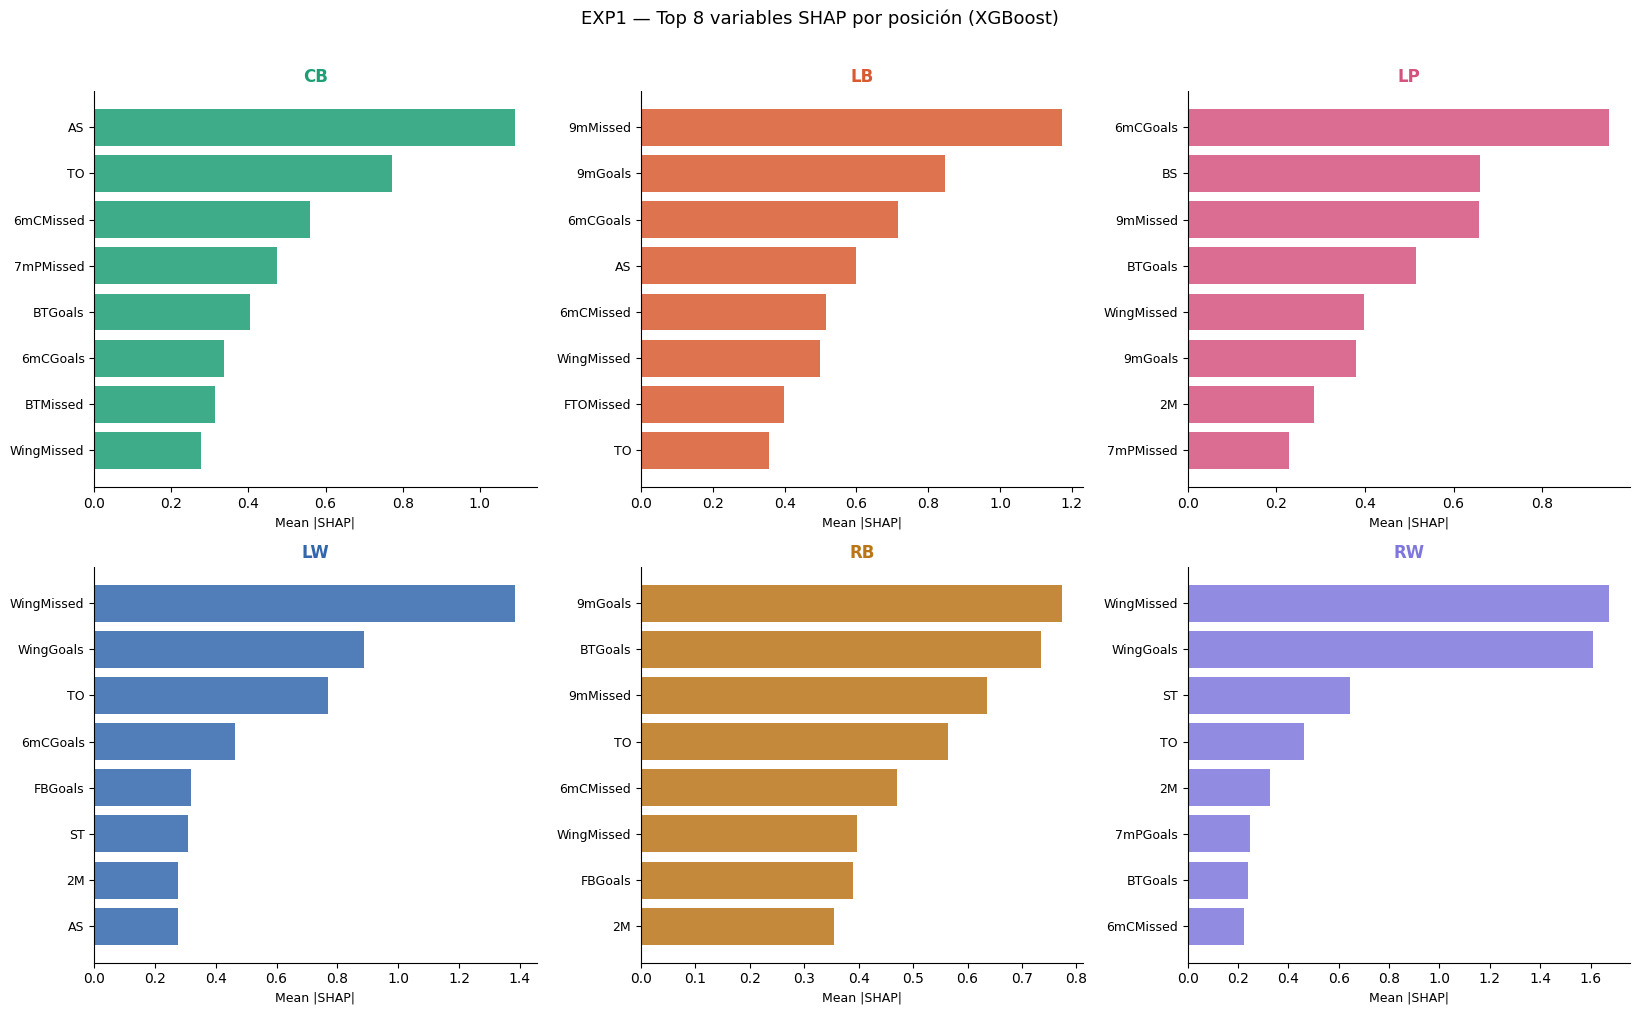

Guardada: position_output/exp1/shap_per_position.png


In [129]:
if not SOLO_EXP2:
    # SHAP por posición — EXP1
    if isinstance(shap_vals1, list):
        shap_list1 = shap_vals1
    elif shap_vals1.ndim == 3:
        shap_list1 = [shap_vals1[:, :, i] for i in range(shap_vals1.shape[2])]
    else:
        shap_list1 = [shap_vals1]
    
    classes1 = le1.classes_
    TOP_N = 8
    n_cls1 = len(classes1)
    n_cols1 = min(n_cls1, 3)
    n_rows1 = math.ceil(n_cls1 / n_cols1)
    
    fig, axes = plt.subplots(n_rows1, n_cols1, figsize=(n_cols1*5.5, n_rows1*5))
    axes = np.array(axes).flatten()
    
    for idx, cls in enumerate(classes1):
        sv = shap_list1[idx]
        mean_abs = np.abs(sv).mean(axis=0)
        importance = pd.Series(mean_abs, index=FEATURE_COLS).sort_values(ascending=False)
        top_vars = importance.head(TOP_N)
        color = POS_COLORS.get(cls, '#888')
        ax = axes[idx]
        ax.barh(range(TOP_N), top_vars.values[::-1], color=color, alpha=0.85)
        ax.set_yticks(range(TOP_N))
        ax.set_yticklabels(top_vars.index[::-1], fontsize=9)
        ax.set_xlabel('Mean |SHAP|', fontsize=9)
        ax.set_title(f'{cls}', fontsize=12, fontweight='bold', color=color)
        ax.spines[['top', 'right']].set_visible(False)
    
    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])
    
    fig.suptitle(f'EXP1 — Top {TOP_N} variables SHAP por posición ({shap_model1_name})',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    fig.savefig(f'{OUT_ROOT}/exp1/shap_per_position.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Guardada: {OUT_ROOT}/exp1/shap_per_position.png')


---

# ══════════════════════════════════════════
# EXPERIMENTO 2 — Posiciones agrupadas 
# LW+RW → Wing | LB+RB → Lateral | CB → Central | LP → Pivote
# (4 clases)
# ══════════════════════════════════════════

In [130]:
# ── Mapeo de posiciones equivalentes ────────────────────────
POS_MAP = {
    'LW': 'Wing',    'RW': 'Wing',
    'LB': 'Lateral', 'RB': 'Lateral',
    'CB': 'Central',
    'LP': 'Pivote',
}

df_exp2 = df_full[df_full[TARGET_COL] != 'GK'].copy()
df_exp2['Grupo'] = df_exp2[TARGET_COL].map(POS_MAP)

print('[EXP 2] Distribución de grupos:')
print(df_exp2['Grupo'].value_counts())

X2 = df_exp2[FEATURE_COLS].values
y2_raw = df_exp2['Grupo'].values

le2 = LabelEncoder()
y2 = le2.fit_transform(y2_raw)
print('\nClases EXP 2:', le2.classes_)

[EXP 2] Distribución de grupos:
Grupo
Lateral    134
Wing        95
Pivote      64
Central     58
Name: count, dtype: int64

Clases EXP 2: ['Central' 'Lateral' 'Pivote' 'Wing']


### 2.1 Split 80/20 estratificado + Estandarización z-score

In [131]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=RANDOM_STATE, stratify=y2
)
print(f'Train: {X2_train.shape[0]}  |  Test: {X2_test.shape[0]}')


Train: 280  |  Test: 71


### 2.2 Random Forest + GridSearchCV

In [132]:
pipe_rf2 = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
])
param_grid_rf2_pipe = {f'model__{k}': v for k, v in param_grid_rf.items()}
gs_rf2 = GridSearchCV(pipe_rf2, param_grid_rf2_pipe, cv=cv5, scoring='accuracy', n_jobs=-1, verbose=0)
gs_rf2.fit(X2_train, y2_train)
rf2 = gs_rf2.best_estimator_

print(f'[EXP2 RF] Mejores hiperparámetros: {gs_rf2.best_params_}')
y2_pred_rf    = rf2.predict(X2_test)
train_acc_rf2 = accuracy_score(y2_train, rf2.predict(X2_train))
cv_rf2        = cross_val_score(rf2, X2_train, y2_train, cv=cv5, scoring='accuracy')
print(f'[EXP2 RF] Train accuracy: {train_acc_rf2:.4f}')
print(f'[EXP2 RF] Test accuracy:  {accuracy_score(y2_test, y2_pred_rf):.4f}')
print(f'[EXP2 RF] Diferencia Train-Test: {train_acc_rf2 - accuracy_score(y2_test, y2_pred_rf):.4f}')
print(classification_report(y2_test, y2_pred_rf, target_names=le2.classes_))


[EXP2 RF] Mejores hiperparámetros: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 50}
[EXP2 RF] Train accuracy: 0.9429
[EXP2 RF] Test accuracy:  0.7746
[EXP2 RF] Diferencia Train-Test: 0.1682
              precision    recall  f1-score   support

     Central       0.60      0.50      0.55        12
     Lateral       0.84      0.78      0.81        27
      Pivote       0.69      0.85      0.76        13
        Wing       0.85      0.89      0.87        19

    accuracy                           0.77        71
   macro avg       0.74      0.75      0.75        71
weighted avg       0.77      0.77      0.77        71



### 2.3 XGBoost + GridSearchCV

In [133]:
pipe_xgb2 = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  xgb.XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1, verbosity=0))
])
param_grid_xgb2_pipe = {f'model__{k}': v for k, v in param_grid_xgb.items()}
gs_xgb2 = GridSearchCV(pipe_xgb2, param_grid_xgb2_pipe, cv=cv5, scoring='accuracy', n_jobs=-1, verbose=0)
gs_xgb2.fit(X2_train, y2_train)
xgb2 = gs_xgb2.best_estimator_

print(f'[EXP2 XGB] Mejores hiperparámetros: {gs_xgb2.best_params_}')
y2_pred_xgb    = xgb2.predict(X2_test)
train_acc_xgb2 = accuracy_score(y2_train, xgb2.predict(X2_train))
cv_xgb2        = cross_val_score(xgb2, X2_train, y2_train, cv=cv5, scoring='accuracy')
print(f'[EXP2 XGB] Train accuracy: {train_acc_xgb2:.4f}')
print(f'[EXP2 XGB] Test accuracy:  {accuracy_score(y2_test, y2_pred_xgb):.4f}')
print(f'[EXP2 XGB] Diferencia Train-Test: {train_acc_xgb2 - accuracy_score(y2_test, y2_pred_xgb):.4f}')
print(classification_report(y2_test, y2_pred_xgb, target_names=le2.classes_))


[EXP2 XGB] Mejores hiperparámetros: {'model__colsample_bytree': 0.7, 'model__learning_rate': 0.5, 'model__max_depth': 6, 'model__min_child_weight': 1, 'model__n_estimators': 15, 'model__reg_alpha': 0.9, 'model__subsample': 0.4}
[EXP2 XGB] Train accuracy: 0.8714
[EXP2 XGB] Test accuracy:  0.7324
[EXP2 XGB] Diferencia Train-Test: 0.1390
              precision    recall  f1-score   support

     Central       0.50      0.33      0.40        12
     Lateral       0.75      0.78      0.76        27
      Pivote       0.69      0.85      0.76        13
        Wing       0.84      0.84      0.84        19

    accuracy                           0.73        71
   macro avg       0.69      0.70      0.69        71
weighted avg       0.72      0.73      0.72        71



### 2.4 SVM + GridSearchCV

In [134]:
pipe_svm2 = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  SVC(class_weight='balanced', random_state=RANDOM_STATE, probability=True))
])
param_grid_svm2_pipe = {f'model__{k}': v for k, v in param_grid_svm.items()}
gs_svm2 = GridSearchCV(pipe_svm2, param_grid_svm2_pipe, cv=cv5, scoring='accuracy', n_jobs=-1, verbose=0)
gs_svm2.fit(X2_train, y2_train)
svm2 = gs_svm2.best_estimator_

print(f'[EXP2 SVM] Mejores hiperparámetros: {gs_svm2.best_params_}')
y2_pred_svm    = svm2.predict(X2_test)
train_acc_svm2 = accuracy_score(y2_train, svm2.predict(X2_train))
cv_svm2        = cross_val_score(svm2, X2_train, y2_train, cv=cv5, scoring='accuracy')
print(f'[EXP2 SVM] Train accuracy: {train_acc_svm2:.4f}')
print(f'[EXP2 SVM] Test accuracy:  {accuracy_score(y2_test, y2_pred_svm):.4f}')
print(f'[EXP2 SVM] Diferencia Train-Test: {train_acc_svm2 - accuracy_score(y2_test, y2_pred_svm):.4f}')
print(classification_report(y2_test, y2_pred_svm, target_names=le2.classes_))


[EXP2 SVM] Mejores hiperparámetros: {'model__C': 2.0, 'model__gamma': 'scale', 'model__kernel': 'linear'}
[EXP2 SVM] Train accuracy: 0.7893
[EXP2 SVM] Test accuracy:  0.6338
[EXP2 SVM] Diferencia Train-Test: 0.1555
              precision    recall  f1-score   support

     Central       0.33      0.50      0.40        12
     Lateral       0.78      0.52      0.62        27
      Pivote       0.53      0.69      0.60        13
        Wing       0.89      0.84      0.86        19

    accuracy                           0.63        71
   macro avg       0.63      0.64      0.62        71
weighted avg       0.69      0.63      0.65        71



### 2.5 Red Neuronal (MLP) + GridSearchCV

In [135]:
pipe_mlp2 = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  MLPClassifier(max_iter=500, early_stopping=True, random_state=RANDOM_STATE))
])
param_grid_mlp2_pipe = {f'model__{k}': v for k, v in param_grid_mlp.items()}
gs_mlp2 = GridSearchCV(pipe_mlp2, param_grid_mlp2_pipe, cv=cv5, scoring='accuracy', n_jobs=-1, verbose=0)
gs_mlp2.fit(X2_train, y2_train)
mlp2 = gs_mlp2.best_estimator_

print(f'[EXP2 MLP] Mejores hiperparámetros: {gs_mlp2.best_params_}')
y2_pred_mlp    = mlp2.predict(X2_test)
train_acc_mlp2 = accuracy_score(y2_train, mlp2.predict(X2_train))
cv_mlp2        = cross_val_score(mlp2, X2_train, y2_train, cv=cv5, scoring='accuracy')
print(f'[EXP2 MLP] Train accuracy: {train_acc_mlp2:.4f}')
print(f'[EXP2 MLP] Test accuracy:  {accuracy_score(y2_test, y2_pred_mlp):.4f}')
print(f'[EXP2 MLP] Diferencia Train-Test: {train_acc_mlp2 - accuracy_score(y2_test, y2_pred_mlp):.4f}')
print(classification_report(y2_test, y2_pred_mlp, target_names=le2.classes_))


[EXP2 MLP] Mejores hiperparámetros: {'model__activation': 'relu', 'model__alpha': 0.0001, 'model__hidden_layer_sizes': (512, 256, 128, 64), 'model__learning_rate': 'adaptive', 'model__learning_rate_init': 0.0005}
[EXP2 MLP] Train accuracy: 0.8464
[EXP2 MLP] Test accuracy:  0.7887
[EXP2 MLP] Diferencia Train-Test: 0.0577
              precision    recall  f1-score   support

     Central       0.50      0.50      0.50        12
     Lateral       0.85      0.81      0.83        27
      Pivote       0.79      0.85      0.81        13
        Wing       0.89      0.89      0.89        19

    accuracy                           0.79        71
   macro avg       0.76      0.76      0.76        71
weighted avg       0.79      0.79      0.79        71



### 2.6 Matrices de confusión — EXP 2 (imágenes)

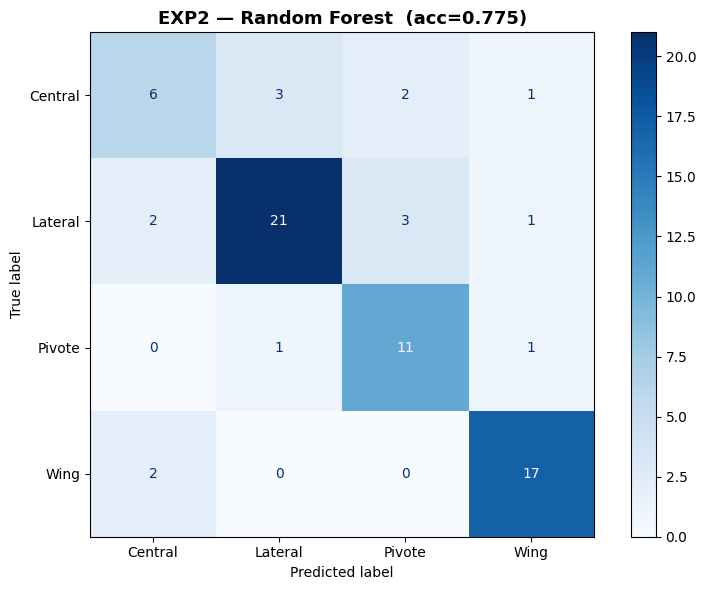

Guardada: position_output/exp2/cm_random_forest.png


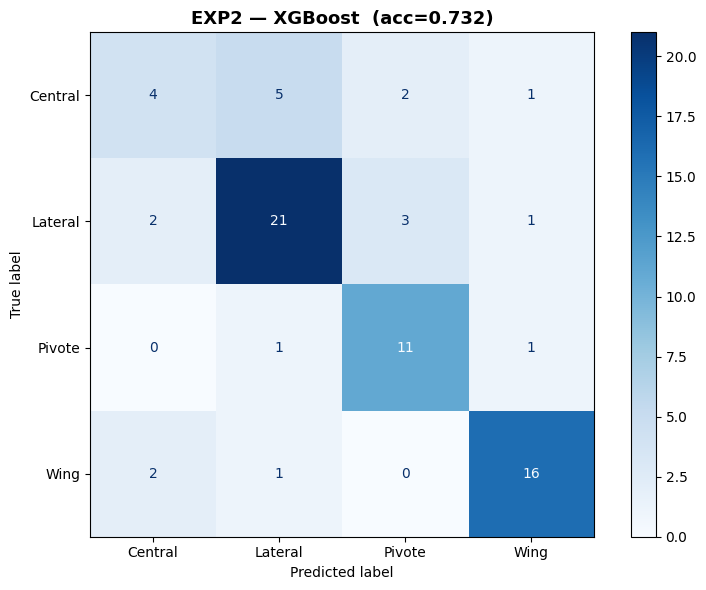

Guardada: position_output/exp2/cm_xgboost.png


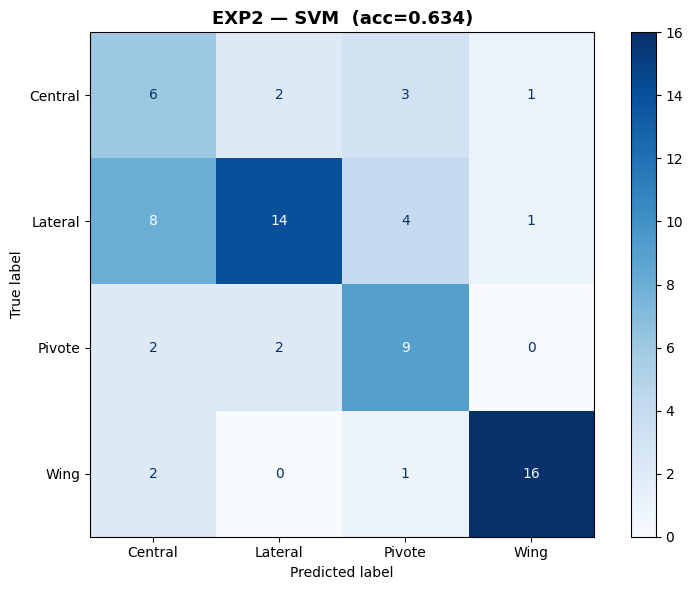

Guardada: position_output/exp2/cm_svm.png


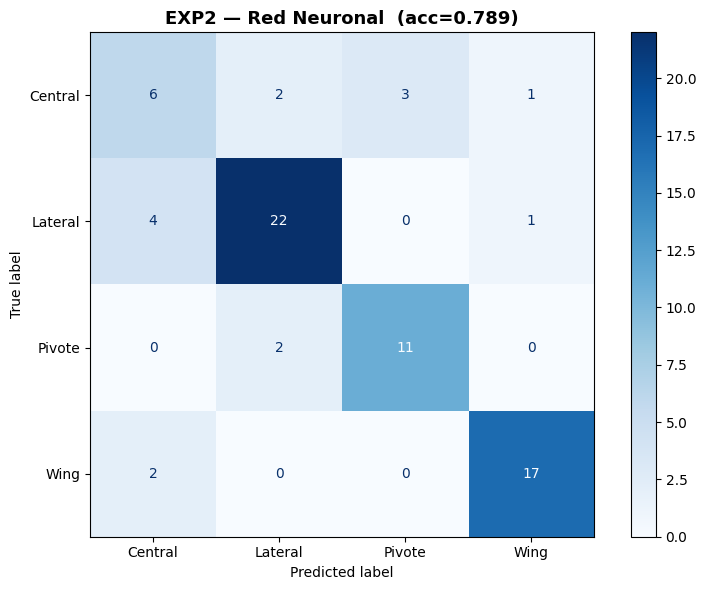

Guardada: position_output/exp2/cm_red_neuronal.png


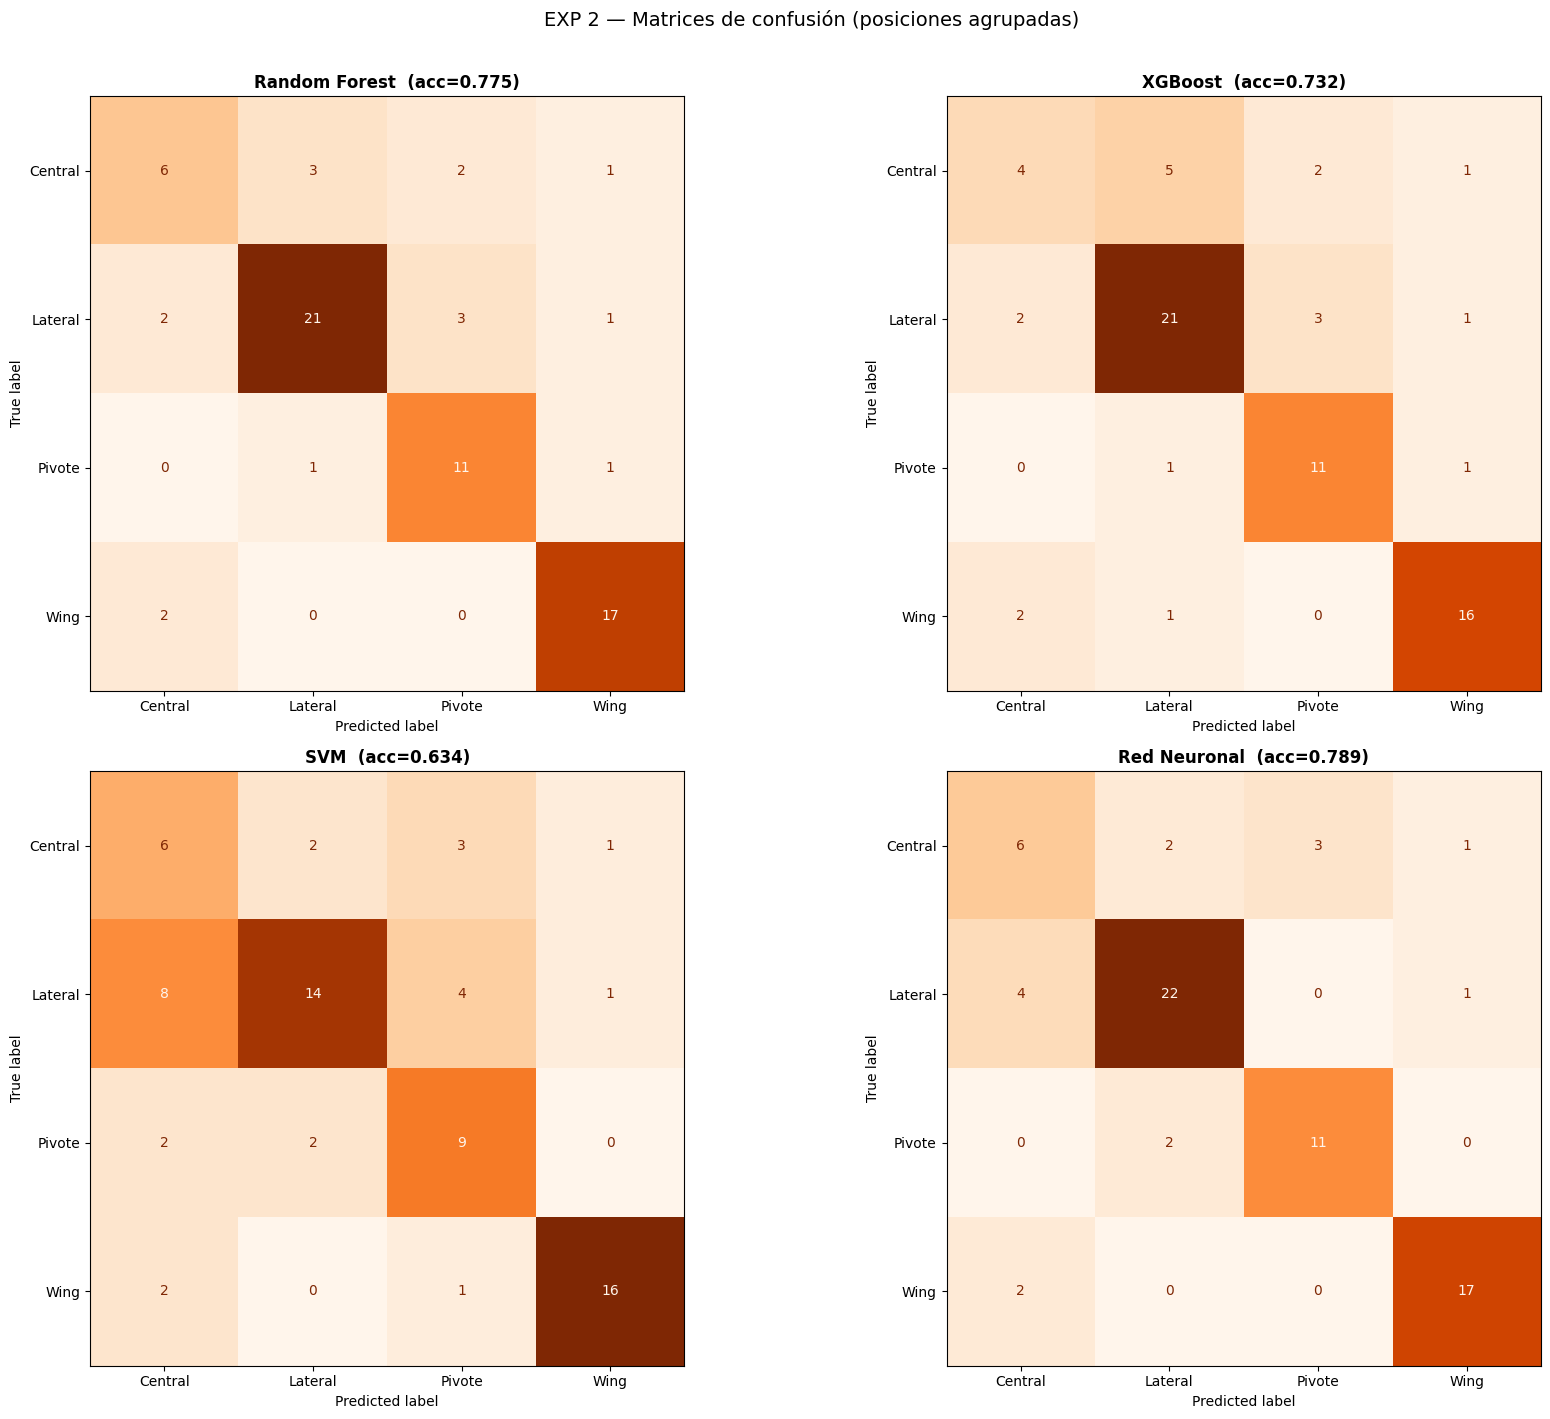

Guardada figura combinada: position_output/exp2/confusion_matrices_all.png


In [136]:
models_exp2 = [
    ('Random Forest', y2_pred_rf),
    ('XGBoost',       y2_pred_xgb),
    ('SVM',           y2_pred_svm),
    ('Red Neuronal',  y2_pred_mlp),
]

for name, preds in models_exp2:
    path = f"{OUT_ROOT}/exp2/cm_{name.replace(' ','_').lower()}.png"
    save_confusion_matrix(y2_test, preds, le2, f'EXP2 — {name}', path)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()
for ax, (name, preds) in zip(axes, models_exp2):
    cm = confusion_matrix(y2_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=le2.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Oranges')
    acc = accuracy_score(y2_test, preds)
    ax.set_title(f'{name}  (acc={acc:.3f})', fontsize=12, fontweight='bold')
plt.suptitle('EXP 2 — Matrices de confusión (posiciones agrupadas)', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/exp2/confusion_matrices_all.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"Guardada figura combinada: {OUT_ROOT}/exp2/confusion_matrices_all.png")

### 2.7 Tabla de métricas — EXP 2

In [137]:
train_accs2 = [train_acc_rf2, train_acc_xgb2, train_acc_svm2, train_acc_mlp2]
cvs2 = [
    (cv_rf2.mean(),  cv_rf2.std()),
    (cv_xgb2.mean(), cv_xgb2.std()),
    (cv_svm2.mean(), cv_svm2.std()),
    (cv_mlp2.mean(), cv_mlp2.std()),
]

rows_exp2 = []
for (name, preds), (cv_m, cv_s), tr_acc in zip(models_exp2, cvs2, train_accs2):
    rows_exp2.append(metrics_table(y2_test, preds, le2, name, cv_m, cv_s, tr_acc))

df_metrics_exp2 = pd.DataFrame(rows_exp2).set_index('Modelo')
col_order2 = ['Train Accuracy', 'CV Accuracy (mean)', 'CV Accuracy (std)',
              'Accuracy', 'Diferencia (Train-CV)', 'F1 (weighted)', 'F1 (macro)',
              'Precision (weighted)', 'Recall (weighted)']
df_metrics_exp2 = df_metrics_exp2[[c for c in col_order2 if c in df_metrics_exp2.columns]]
print('=== EXP 2 — Métricas globales ===')
display(df_metrics_exp2.style.background_gradient(subset=['Diferencia (Train-CV)'], cmap='RdYlGn_r'))
df_metrics_exp2.to_csv(f'{OUT_ROOT}/exp2/metrics_global.csv')

rows_class_exp2 = []
for name, preds in models_exp2:
    rows_class_exp2.extend(per_class_table(y2_test, preds, le2, name))
df_class_exp2 = pd.DataFrame(rows_class_exp2)
print('\n=== EXP 2 — Métricas por clase ===')
display(df_class_exp2)
df_class_exp2.to_csv(f'{OUT_ROOT}/exp2/metrics_per_class.csv', index=False)


=== EXP 2 — Métricas globales ===


,Train Accuracy,CV Accuracy (mean),CV Accuracy (std),Accuracy,Diferencia (Train-CV),F1 (weighted),F1 (macro),Precision (weighted),Recall (weighted)
Modelo,,,,,,,,,
Random Forest,0.942900,0.742900,0.040100,0.774600,0.200000,0.771500,0.745900,0.774200,0.774600
XGBoost,0.871400,0.746400,0.061200,0.732400,0.125000,0.722300,0.691100,0.721000,0.732400
SVM,0.789300,0.732100,0.071400,0.633800,0.057100,0.645500,0.621800,0.686900,0.633800
Red Neuronal,0.846400,0.710700,0.058000,0.788700,0.135700,0.788800,0.759900,0.789600,0.788700



=== EXP 2 — Métricas por clase ===


,Modelo,Clase,Precision,Recall,F1-score
0,Random Forest,Central,0.6000,0.5000,0.5455
1,Random Forest,Lateral,0.8400,0.7778,0.8077
2,Random Forest,Pivote,0.6875,0.8462,0.7586
3,Random Forest,Wing,0.8500,0.8947,0.8718
4,XGBoost,Central,0.5000,0.3333,0.4000
5,XGBoost,Lateral,0.7500,0.7778,0.7636
6,XGBoost,Pivote,0.6875,0.8462,0.7586
7,XGBoost,Wing,0.8421,0.8421,0.8421
8,SVM,Central,0.3333,0.5000,0.4000
9,SVM,Lateral,0.7778,0.5185,0.6222


### 2.9 Comprobación de sobreajuste — EXP 2

Mismo análisis que en EXP 1: comparación Train / CV / Test y curvas de aprendizaje para los 4 modelos con posiciones agrupadas.

=== EXP 2 — Comprobación de sobreajuste ===


,Train Accuracy,CV Accuracy (mean),CV Std (±),Test Accuracy,Diferencia Train-CV,Diferencia Train-Test
Modelo,,,,,,
Random Forest,0.942900,0.742900,0.040100,0.774600,0.200000,0.168200
XGBoost,0.871400,0.746400,0.061200,0.732400,0.125000,0.139000
SVM,0.789300,0.732100,0.071400,0.633800,0.057100,0.155500
Red Neuronal,0.846400,0.710700,0.058000,0.788700,0.135700,0.057700


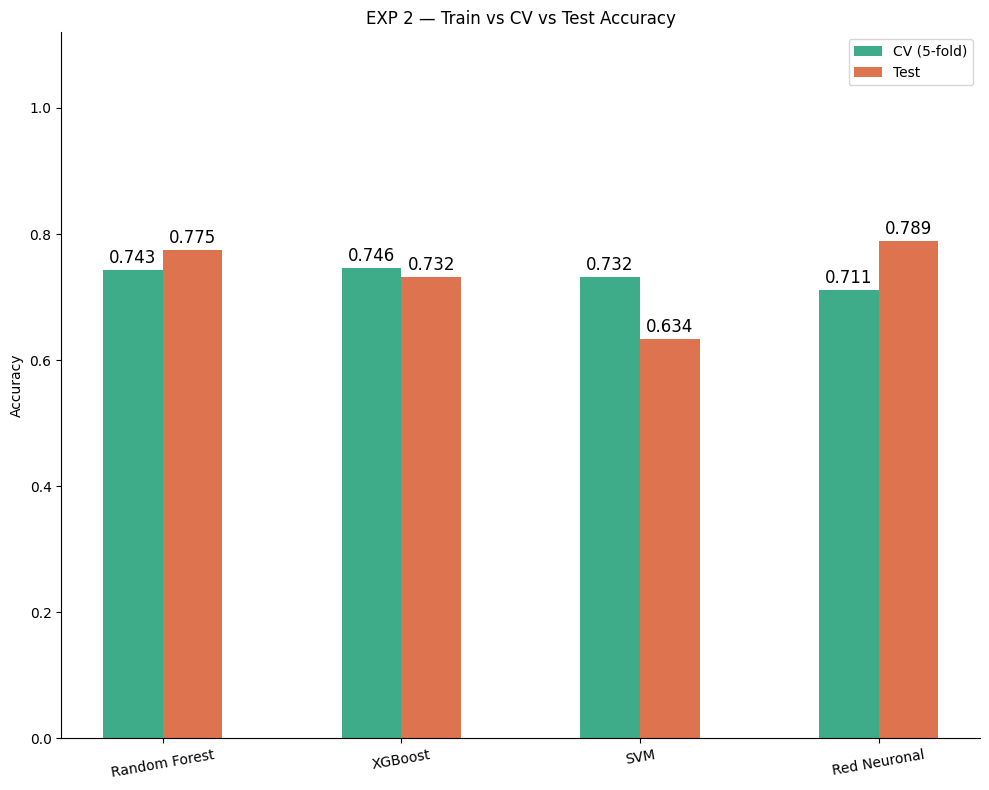

Guardada: position_output/exp2/overfit_train_cv_test.png


In [138]:
# ── Tabla resumen Train / CV / Test — EXP2 ──────────────────
models_exp2_dict = {
    'Random Forest': (rf2,  train_acc_rf2,  cv_rf2,  y2_pred_rf),
    'XGBoost':       (xgb2, train_acc_xgb2, cv_xgb2, y2_pred_xgb),
    'SVM':           (svm2, train_acc_svm2, cv_svm2, y2_pred_svm),
    'Red Neuronal':  (mlp2, train_acc_mlp2, cv_mlp2, y2_pred_mlp),
}

overfit_rows2 = []
for mname, (model, tr_acc, cv_scores, preds) in models_exp2_dict.items():
    test_acc = accuracy_score(y2_test, preds)
    overfit_rows2.append({
        'Modelo':            mname,
        'Train Accuracy':    round(tr_acc, 4),
        'CV Accuracy (mean)':round(cv_scores.mean(), 4),
        'CV Std (±)':        round(cv_scores.std(), 4),
        'Test Accuracy':     round(test_acc, 4),
        'Diferencia Train-CV':      round(tr_acc - cv_scores.mean(), 4),
        'Diferencia Train-Test':    round(tr_acc - test_acc, 4),
    })

df_overfit2 = pd.DataFrame(overfit_rows2).set_index('Modelo')
print('=== EXP 2 — Comprobación de sobreajuste ===')
display(df_overfit2.style.background_gradient(subset=['Diferencia Train-CV', 'Diferencia Train-Test'],
                                               cmap='RdYlGn_r'))
df_overfit2.to_csv(f'{OUT_ROOT}/exp2/overfit_diagnosis.csv')

width  = 0.25

# ── Gráfico: Train vs CV vs Test Accuracy — EXP2 ────────────
fig, ax = plt.subplots(figsize=(10, 8))
x = np.arange(len(overfit_rows2))
names2   = [r['Modelo'] for r in overfit_rows2]
tr_vals2 = [r['Train Accuracy']     for r in overfit_rows2]
cv_vals2 = [r['CV Accuracy (mean)'] for r in overfit_rows2]
te_vals2 = [r['Test Accuracy']      for r in overfit_rows2]

b2 = ax.bar(x - width/2, cv_vals2, width, label='CV (5-fold)', color='#1d9e75', alpha=0.85)
b3 = ax.bar(x + width/2, te_vals2, width, label='Test',        color='#d85a30', alpha=0.85)

for bars in [b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(names2, rotation=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Accuracy')
ax.set_title('EXP 2 — Train vs CV vs Test Accuracy', fontsize=12)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/exp2/overfit_train_cv_test.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Guardada: {OUT_ROOT}/exp2/overfit_train_cv_test.png')


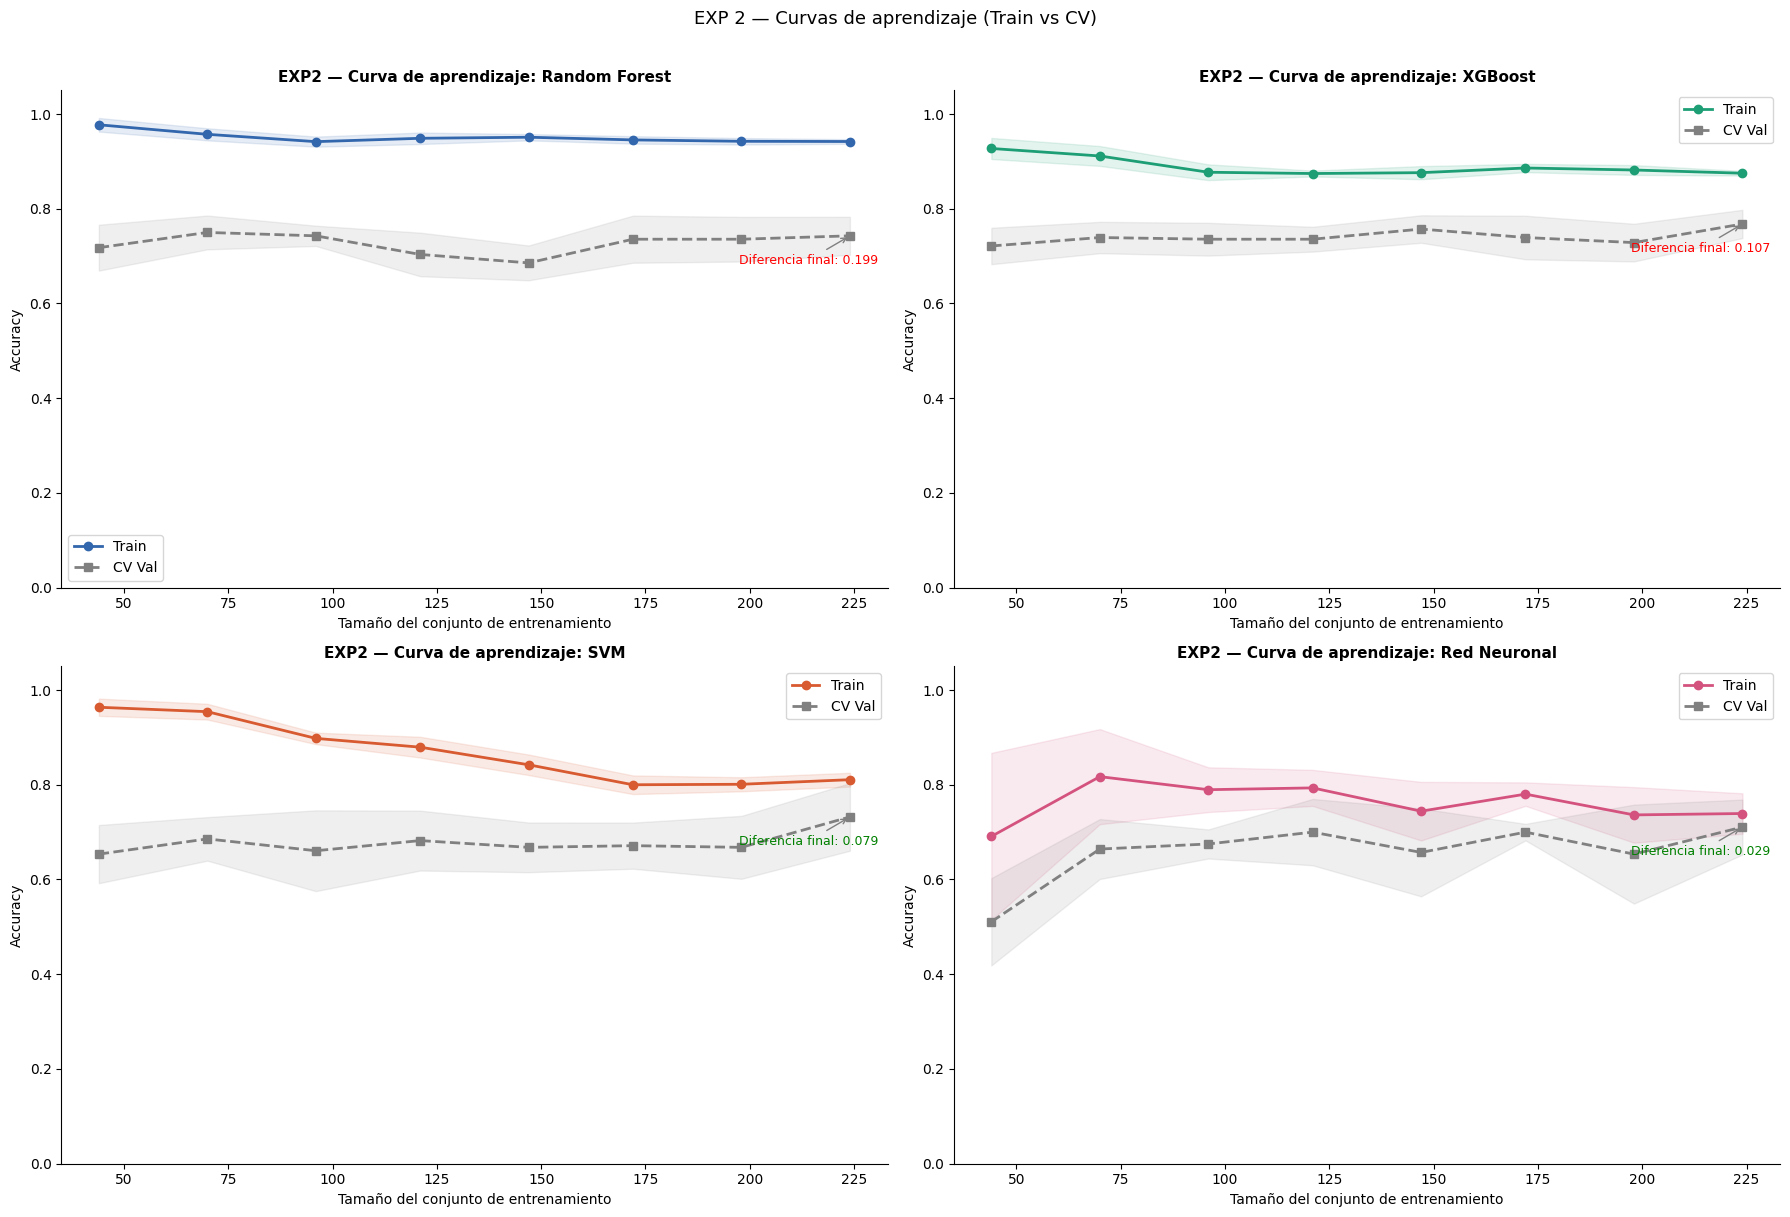

Guardada: position_output/exp2/learning_curves.png


In [139]:
# ── Curvas de aprendizaje — EXP 2 ───────────────────────────
lc_models2 = [
    ('Random Forest', rf2,  '#3266ad'),
    ('XGBoost',       xgb2, '#1d9e75'),
    ('SVM',           svm2, '#d85a30'),
    ('Red Neuronal',  mlp2, '#d4537e'),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax, (mname, model, color) in zip(axes, lc_models2):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X2_train, y2_train,
        cv=cv5, scoring='accuracy',
        train_sizes=np.linspace(0.2, 1.0, 8),
        n_jobs=-1
    )
    tr_mean  = train_scores.mean(axis=1)
    tr_std   = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std  = val_scores.std(axis=1)

    ax.plot(train_sizes, tr_mean,  'o-', color=color,   label='Train',  linewidth=2)
    ax.plot(train_sizes, val_mean, 's--', color='gray', label='CV Val', linewidth=2)
    ax.fill_between(train_sizes, tr_mean - tr_std,  tr_mean + tr_std,  alpha=0.12, color=color)
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.12, color='gray')
    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'EXP2 — Curva de aprendizaje: {mname}', fontsize=11, fontweight='bold')
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.spines[['top', 'right']].set_visible(False)
    Diferencia = tr_mean[-1] - val_mean[-1]
    ax.annotate(f'Diferencia final: {Diferencia:.3f}',
                xy=(train_sizes[-1], val_mean[-1]),
                xytext=(-80, -20), textcoords='offset points',
                fontsize=9, color='red' if Diferencia > 0.10 else 'green',
                arrowprops=dict(arrowstyle='->', color='gray'))

plt.suptitle('EXP 2 — Curvas de aprendizaje (Train vs CV)', fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/exp2/learning_curves.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Guardada: {OUT_ROOT}/exp2/learning_curves.png')


### 2.8 Análisis SHAP — EXP 2 (mejor modelo)

Mejor modelo EXP2: Red Neuronal  (0.7887)


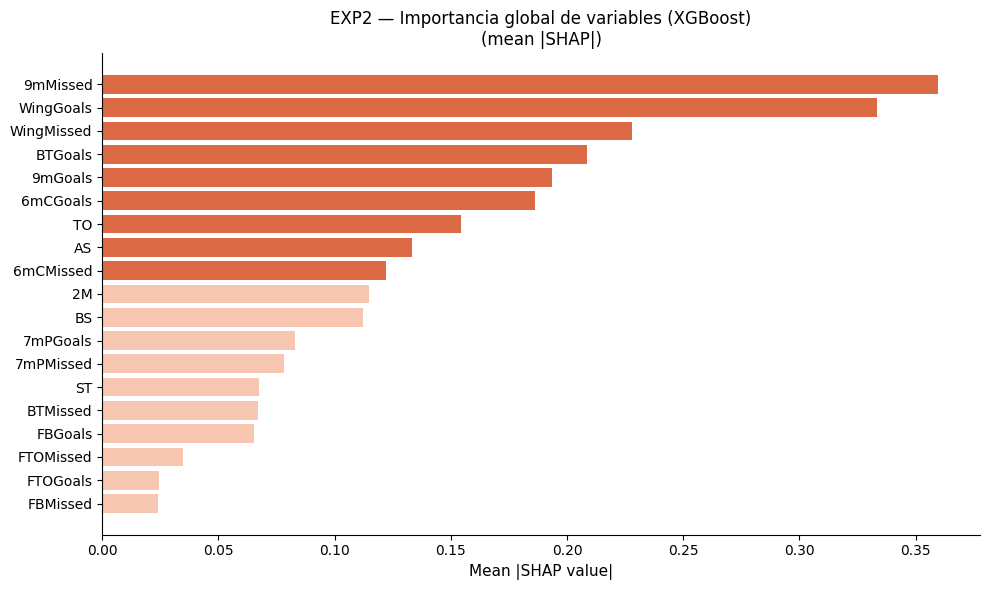


Top 10 variables más importantes (EXP2):


,mean_abs_shap
9mMissed,0.3598
WingGoals,0.3334
WingMissed,0.2280
BTGoals,0.2084
9mGoals,0.1937
6mCGoals,0.1864
TO,0.1544
AS,0.1334
6mCMissed,0.1222
2M,0.1148


In [140]:
accs2 = {name: accuracy_score(y2_test, p) for name, p in models_exp2}
best_name2 = max(accs2, key=accs2.get)
best_model2_map = {'Random Forest': rf2, 'XGBoost': xgb2}
shap_model2_name = best_name2 if best_name2 in best_model2_map else 'XGBoost'
shap_pipe2  = best_model2_map[shap_model2_name]
shap_model2 = shap_pipe2.named_steps['model']
print(f'Mejor modelo EXP2: {best_name2}  ({accs2[best_name2]:.4f})')

X2_all_full = df_exp2[FEATURE_COLS].values
X2_all_sc   = shap_pipe2.named_steps['scaler'].transform(X2_all_full)

explainer2 = shap.TreeExplainer(shap_model2)
shap_vals2 = explainer2.shap_values(X2_all_sc)

if isinstance(shap_vals2, list):
    global_shap2 = np.mean([np.abs(sv).mean(axis=0) for sv in shap_vals2], axis=0)
else:
    global_shap2 = np.abs(shap_vals2).mean(axis=(0, 2)) if shap_vals2.ndim == 3 else np.abs(shap_vals2).mean(axis=0)

shap_imp2 = pd.Series(global_shap2, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar2 = ['#d85a30' if v > shap_imp2.median() else '#f5c0a8' for v in shap_imp2.values]
ax.barh(shap_imp2.index[::-1], shap_imp2.values[::-1], color=colors_bar2[::-1], alpha=0.9)
ax.set_xlabel('Mean |SHAP value|', fontsize=11)
ax.set_title(f'EXP2 — Importancia global de variables ({shap_model2_name})\n(mean |SHAP|)', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/exp2/shap_global_importance.png', dpi=130, bbox_inches='tight')
plt.show()

print('\nTop 10 variables más importantes (EXP2):')
display(shap_imp2.head(10).to_frame('mean_abs_shap').round(4))


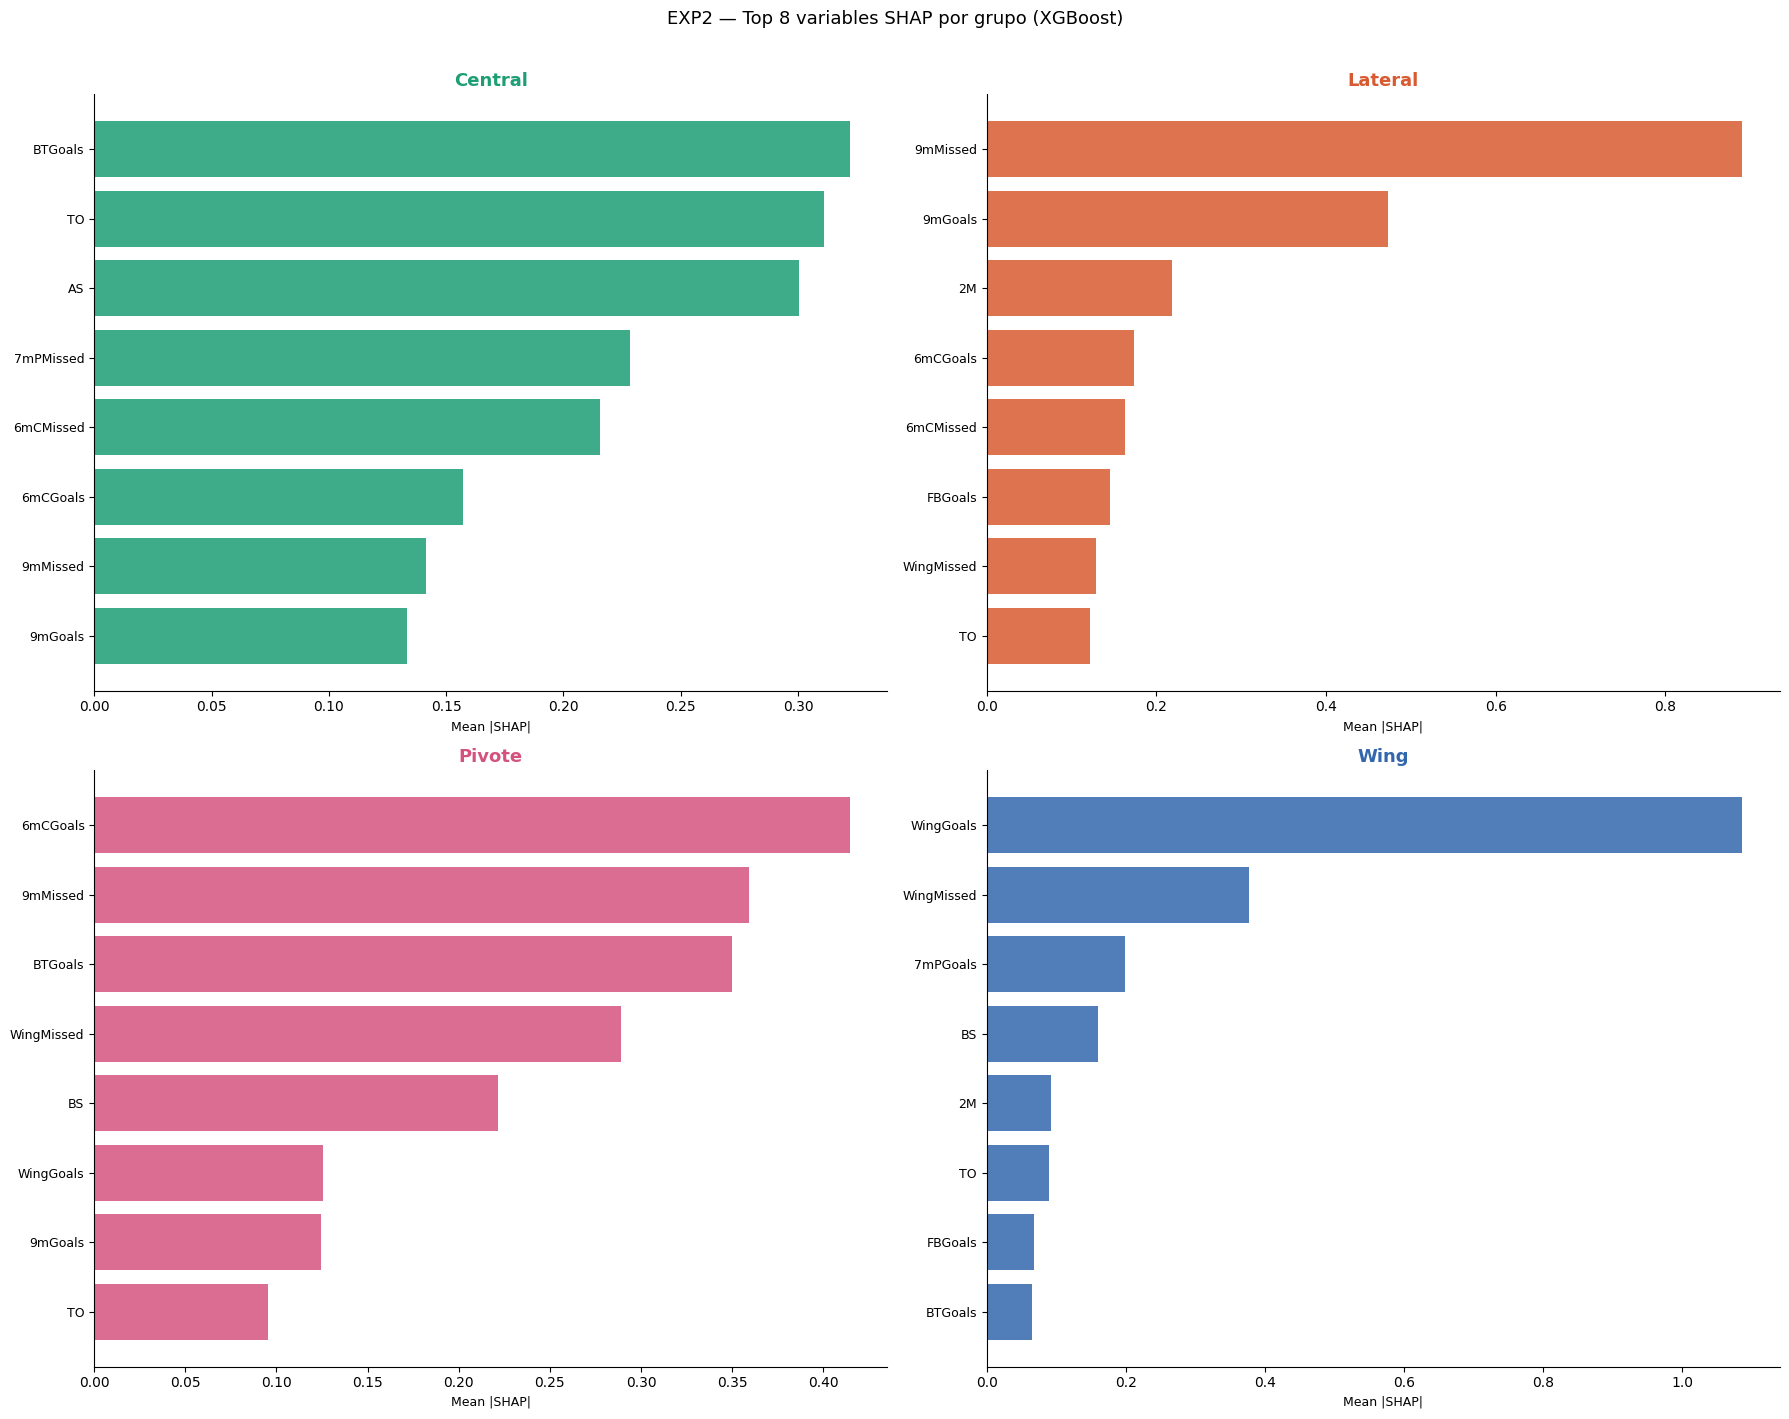

Guardada: position_output/exp2/shap_per_group.png


In [141]:
# SHAP por grupo — EXP2
if isinstance(shap_vals2, list):
    shap_list2 = shap_vals2
elif shap_vals2.ndim == 3:
    shap_list2 = [shap_vals2[:, :, i] for i in range(shap_vals2.shape[2])]
else:
    shap_list2 = [shap_vals2]

TOP_N = 8
classes2 = le2.classes_
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for idx, cls in enumerate(classes2):
    sv = shap_list2[idx]
    mean_abs = np.abs(sv).mean(axis=0)
    importance = pd.Series(mean_abs, index=FEATURE_COLS).sort_values(ascending=False)
    top_vars = importance.head(TOP_N)
    color = POS_COLORS.get(cls, '#888')
    ax = axes[idx]
    ax.barh(range(TOP_N), top_vars.values[::-1], color=color, alpha=0.85)
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top_vars.index[::-1], fontsize=9)
    ax.set_xlabel('Mean |SHAP|', fontsize=9)
    ax.set_title(f'{cls}', fontsize=13, fontweight='bold', color=color)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(f'EXP2 — Top {TOP_N} variables SHAP por grupo ({shap_model2_name})',
             fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/exp2/shap_per_group.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardada: {OUT_ROOT}/exp2/shap_per_group.png')

---

# ══════════════════════════════════════════
# COMPARATIVA ENTRE EXPERIMENTOS
# ══════════════════════════════════════════

  RESUMEN DE EXPERIMENTOS

--- EXP 1 (6 clases) ---


,Accuracy,F1 (weighted),F1 (macro),CV Accuracy (mean)
Modelo,,,,
Random Forest,0.5915,0.5428,0.5253,0.5464
XGBoost,0.6338,0.6029,0.5895,0.5786
SVM,0.5352,0.5268,0.5175,0.5107
Red Neuronal,0.5211,0.4615,0.4147,0.4893



--- EXP 2 (4 clases) ---


,Accuracy,F1 (weighted),F1 (macro),CV Accuracy (mean)
Modelo,,,,
Random Forest,0.7746,0.7715,0.7459,0.7429
XGBoost,0.7324,0.7223,0.6911,0.7464
SVM,0.6338,0.6455,0.6218,0.7321
Red Neuronal,0.7887,0.7888,0.7599,0.7107


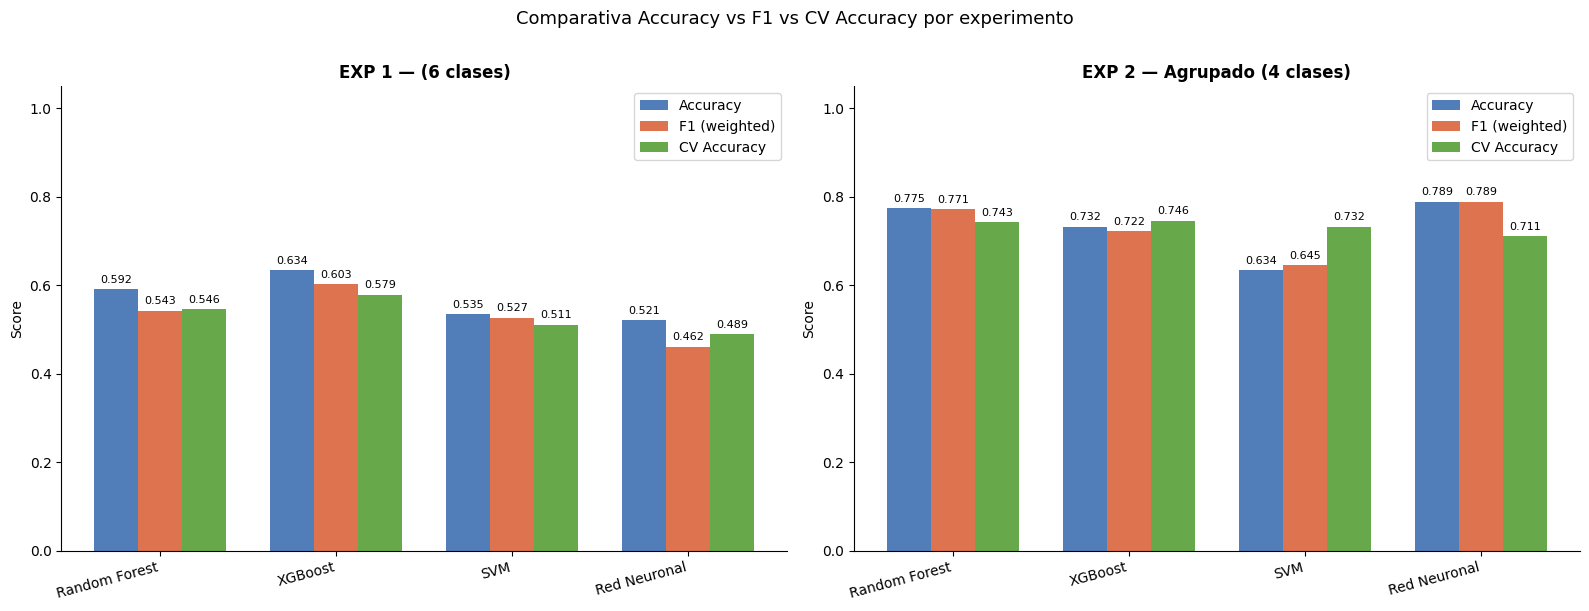

Guardada: position_output/comparativa_experimentos.png


In [142]:
print('=' * 55)
print('  RESUMEN DE EXPERIMENTOS')
print('=' * 55)

if not SOLO_EXP2:
    print('\n--- EXP 1 (6 clases) ---')
    display(df_metrics_exp1[['Accuracy', 'F1 (weighted)', 'F1 (macro)', 'CV Accuracy (mean)']])

print('\n--- EXP 2 (4 clases) ---')
display(df_metrics_exp2[['Accuracy', 'F1 (weighted)', 'F1 (macro)', 'CV Accuracy (mean)']])

pairs_met = []
if not SOLO_EXP2:
    pairs_met.append((df_metrics_exp1, 'EXP 1 — (6 clases)'))
pairs_met.append((df_metrics_exp2, 'EXP 2 — Agrupado (4 clases)'))

fig, axes = plt.subplots(1, len(pairs_met), figsize=(8*len(pairs_met), 6), sharey=False)

if len(pairs_met) == 1:
    axes = [axes]

for ax, (df_met, title) in zip(axes, pairs_met):
    x = range(len(df_met))
    width = 0.25

    bars1 = ax.bar(
        [i - width for i in x],
        df_met['Accuracy'],
        width,
        label='Accuracy',
        color='#3266ad',
        alpha=0.85
    )

    bars2 = ax.bar(
        x,
        df_met['F1 (weighted)'],
        width,
        label='F1 (weighted)',
        color='#d85a30',
        alpha=0.85
    )

    bars3 = ax.bar(
        [i + width for i in x],
        df_met['CV Accuracy (mean)'],
        width,
        label='CV Accuracy',
        color='#4c9a2a',
        alpha=0.85
    )

    ax.set_xticks(list(x))
    ax.set_xticklabels(df_met.index, rotation=15, ha='right')
    ax.set_ylim(0, 1.05)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)

    for bar in bars1:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

    for bar in bars2:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

    for bar in bars3:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.suptitle('Comparativa Accuracy vs F1 vs CV Accuracy por experimento', fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/comparativa_experimentos.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'Guardada: {OUT_ROOT}/comparativa_experimentos.png')

---

# ══════════════════════════════════════════
# MODELO FINAL ROBUSTO
# Entrenar con el 100% de los datos (train+test)
# una vez validados los experimentos
# ══════════════════════════════════════════

In [143]:
if not SOLO_EXP2:
    print('=== MODELO FINAL — EXP 1 () ===')

    X1_all_full = df_exp1[FEATURE_COLS].values
    y1_all_full = le1.transform(df_exp1[TARGET_COL].values)

    scaler1_final = StandardScaler()
    X1_all_sc_final = scaler1_final.fit_transform(X1_all_full)

    rf1_params = {k.replace('model__', ''): v for k, v in gs_rf1.best_params_.items()}
    rf1_final = RandomForestClassifier(
        **rf1_params, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    )
    rf1_final.fit(X1_all_sc_final, y1_all_full)
    print(f'RF EXP1 final entrenado con {len(y1_all_full)} instancias. Clases: {le1.classes_}')

print('\n=== MODELO FINAL — EXP 2 (agrupado) ===')

X2_all_full = df_exp2[FEATURE_COLS].values
y2_all_full = le2.transform(df_exp2['Grupo'].values)

scaler2_final = StandardScaler()
X2_all_sc_final = scaler2_final.fit_transform(X2_all_full)

rf2_params = {k.replace('model__', ''): v for k, v in gs_rf2.best_params_.items()}
rf2_final = RandomForestClassifier(
    **rf2_params, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
rf2_final.fit(X2_all_sc_final, y2_all_full)
print(f'RF EXP2 final entrenado con {len(y2_all_full)} instancias. Clases: {le2.classes_}')


=== MODELO FINAL — EXP 1 () ===
RF EXP1 final entrenado con 351 instancias. Clases: ['CB' 'LB' 'LP' 'LW' 'RB' 'RW']

=== MODELO FINAL — EXP 2 (agrupado) ===
RF EXP2 final entrenado con 351 instancias. Clases: ['Central' 'Lateral' 'Pivote' 'Wing']


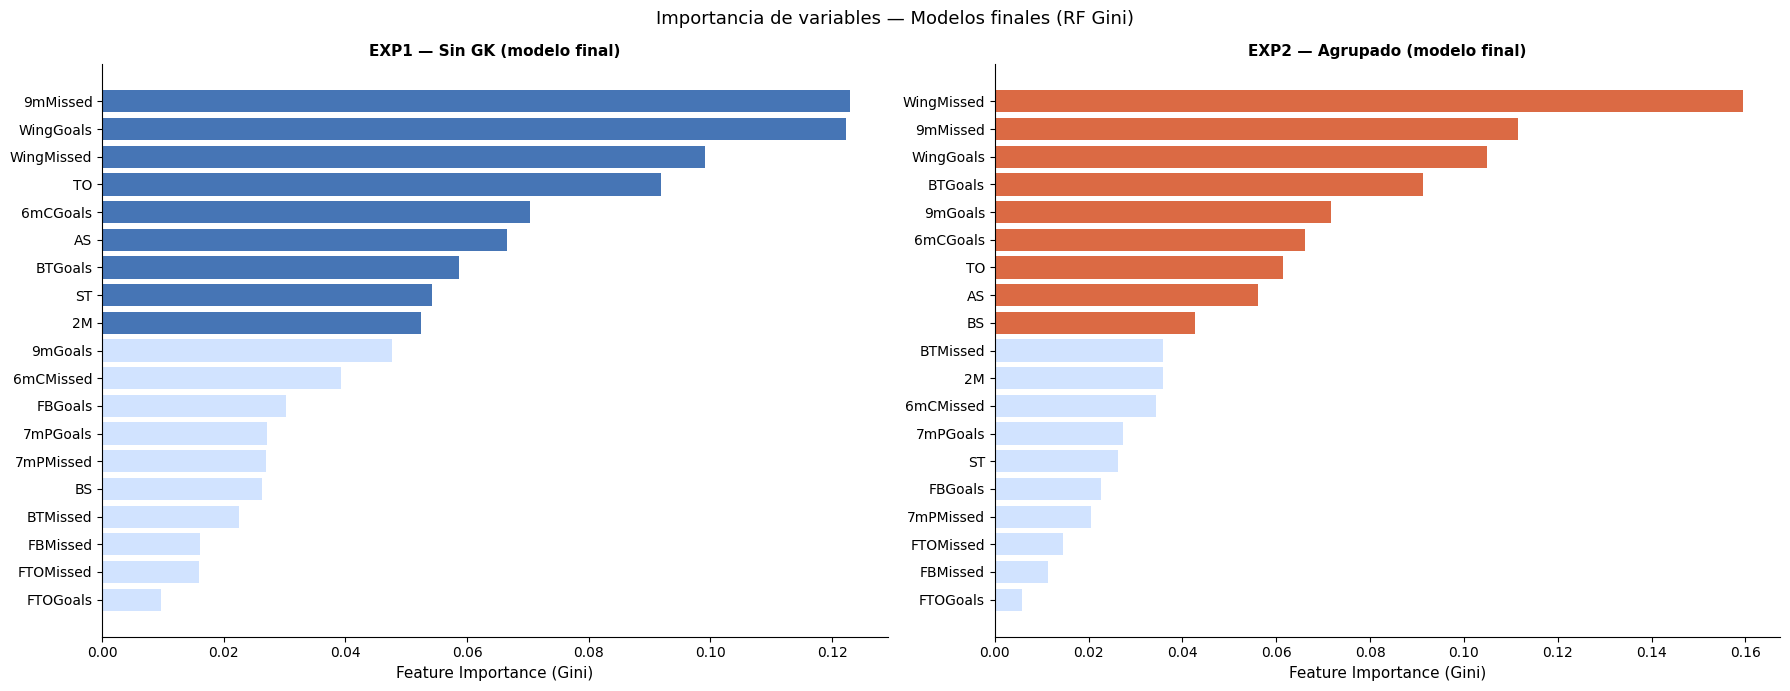

 Guardada: position_output/final/feature_importance_final.png
Todos los artefactos en: position_output/


In [144]:
# ── Importancia de variables del modelo final (RF, Gini) ────
pairs = []
if not SOLO_EXP2:
    pairs.append((rf1_final, scaler1_final, 'EXP1 — Sin GK (modelo final)', '#3266ad'))
pairs.append((rf2_final, scaler2_final, 'EXP2 — Agrupado (modelo final)', '#d85a30'))
fig, axes = plt.subplots(1, len(pairs), figsize=(9*len(pairs), 7))
if len(pairs) == 1: axes = [axes]
for ax, (rf_fin, scaler_fin, title_exp, color_bar) in zip(axes, pairs):
    imp = pd.Series(rf_fin.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
    colors_imp = [color_bar if v > imp.median() else '#cce0ff' for v in imp.values]
    ax.barh(imp.index[::-1], imp.values[::-1], color=colors_imp[::-1], alpha=0.9)
    ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
    ax.set_title(title_exp, fontsize=11, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Importancia de variables — Modelos finales (RF Gini)', fontsize=13)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/final/feature_importance_final.png', dpi=130, bbox_inches='tight')
plt.show()
print(f' Guardada: {OUT_ROOT}/final/feature_importance_final.png')

print(f'Todos los artefactos en: {OUT_ROOT}/')

### SHAP — Modelos finales (train+test completo)

Análisis SHAP sobre los modelos finales entrenados con el 100% de los datos. Al haber visto más ejemplos, los valores de importancia son más estables y representativos que los obtenidos durante los experimentos.


=== SHAP EXP1 — (6 clases) ===


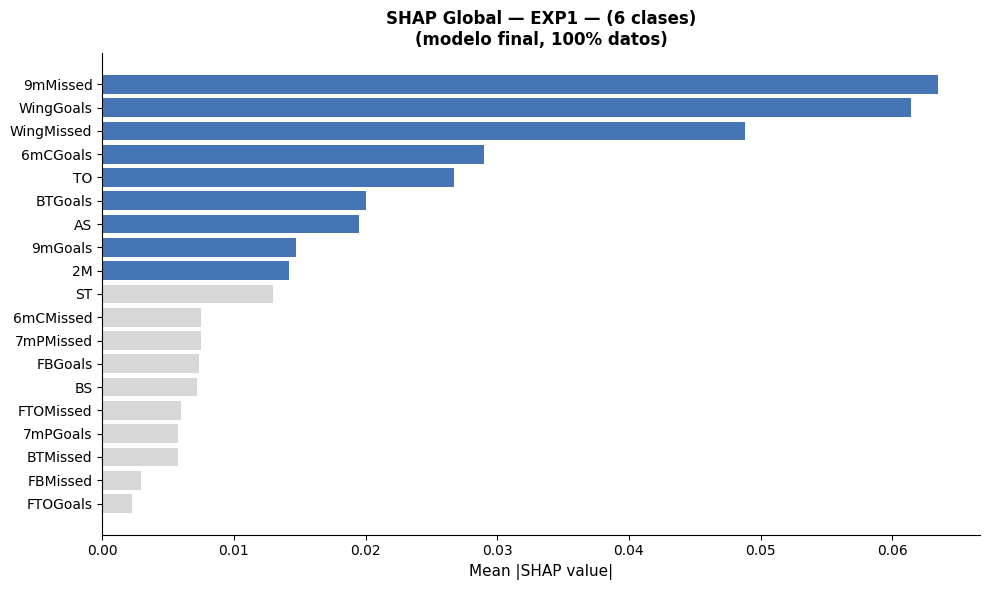

position_output/final/shap_exp1_final_global.png

Top 10 variables:


,mean_abs_shap
9mMissed,0.0635
WingGoals,0.0615
WingMissed,0.0488
6mCGoals,0.0290
TO,0.0267
BTGoals,0.0200
AS,0.0195
9mGoals,0.0147
2M,0.0142
ST,0.0129


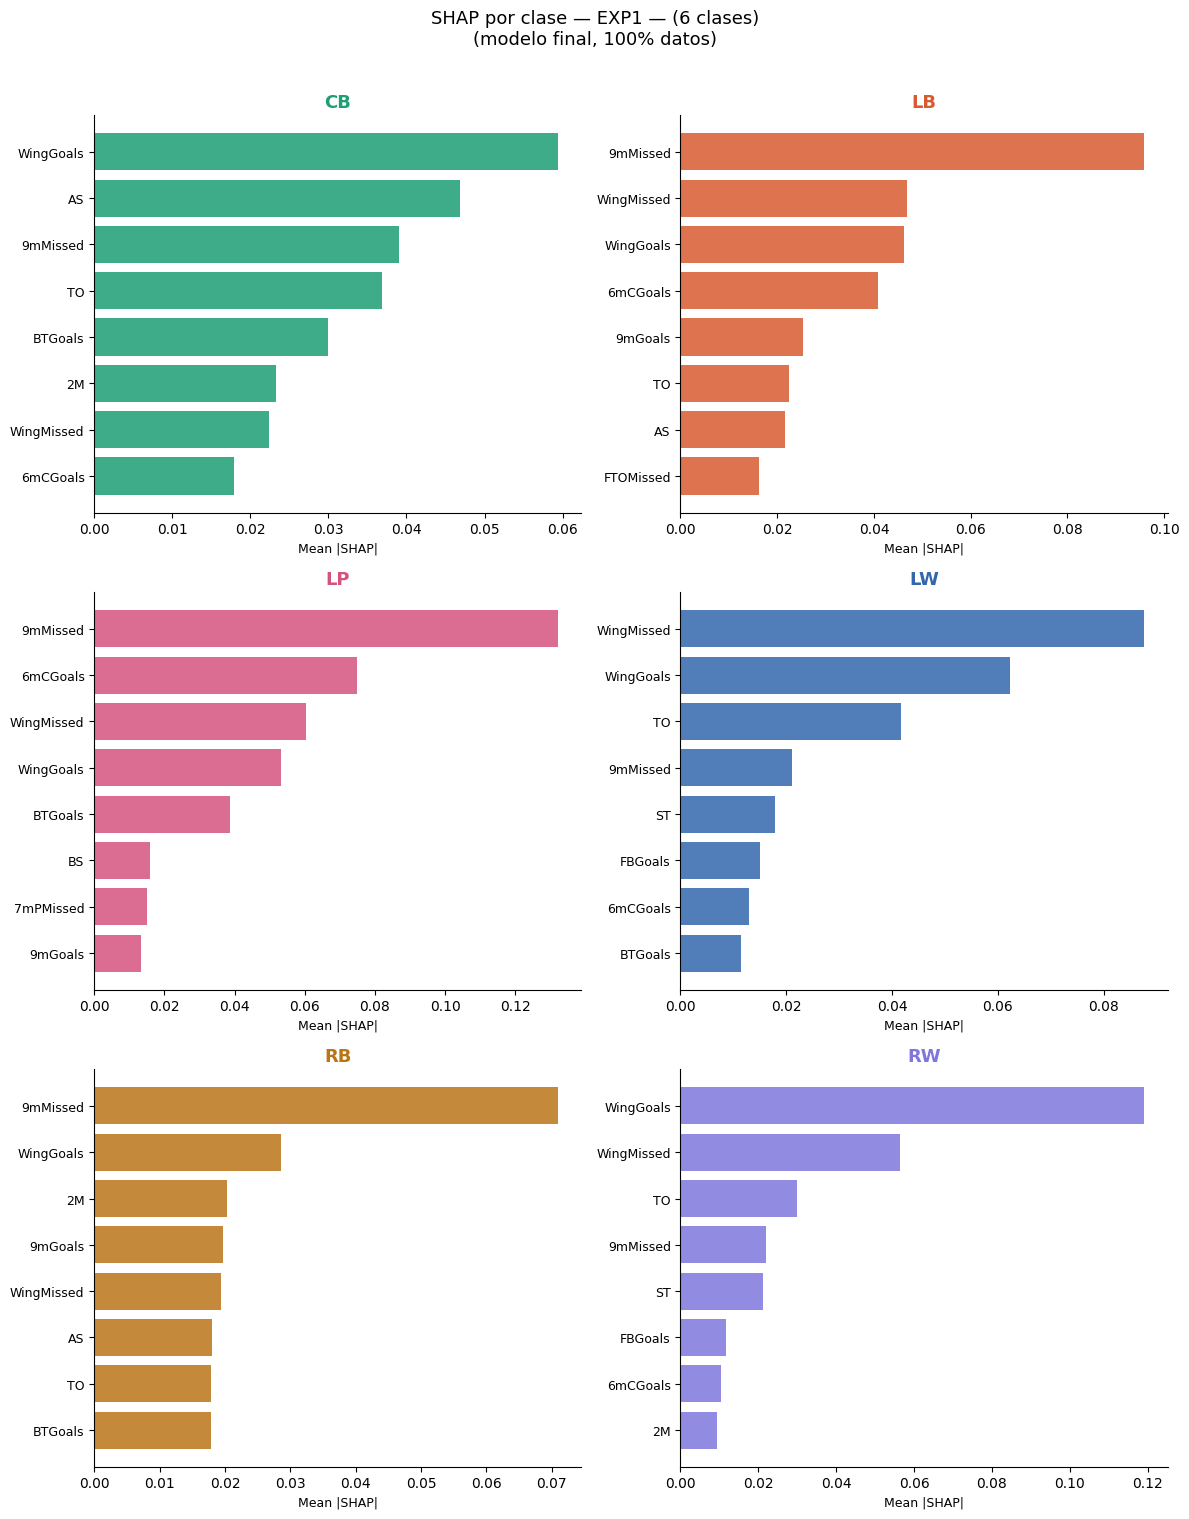

position_output/final/shap_exp1_final_per_class.png

=== SHAP EXP2 — Agrupado (4 clases) ===


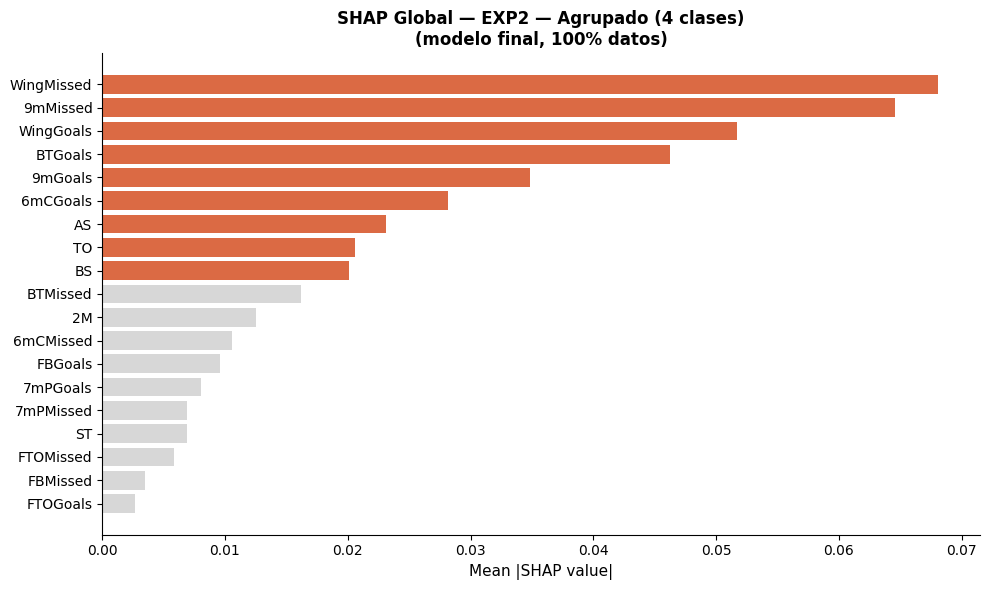

position_output/final/shap_exp2_final_global.png

Top 10 variables:


,mean_abs_shap
WingMissed,0.0681
9mMissed,0.0646
WingGoals,0.0517
BTGoals,0.0463
9mGoals,0.0348
6mCGoals,0.0282
AS,0.0231
TO,0.0206
BS,0.0201
BTMissed,0.0162


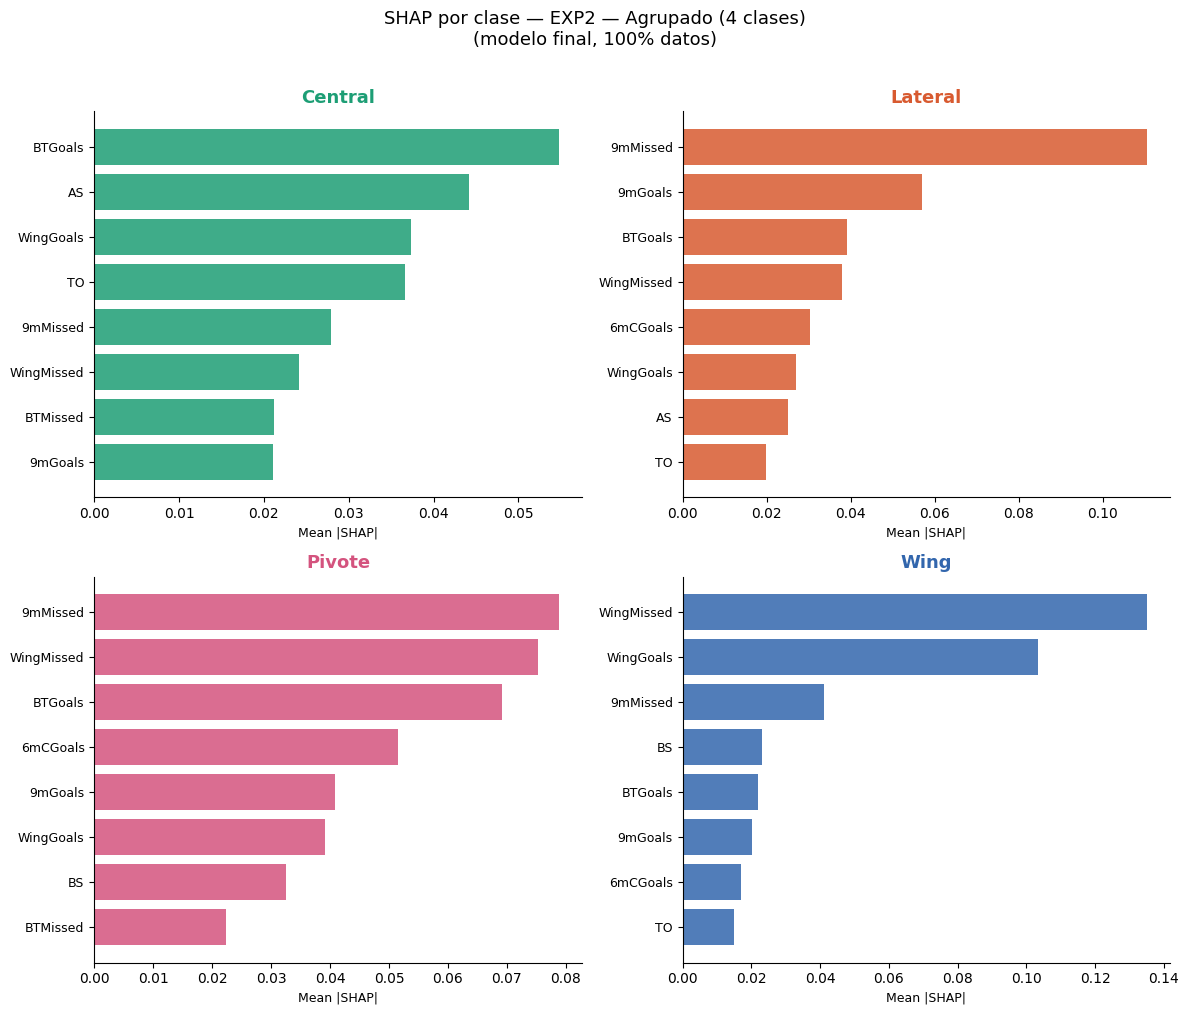

position_output/final/shap_exp2_final_per_class.png


In [145]:
# ── SHAP sobre modelos finales ───────────────────────────────
finals = []
if not SOLO_EXP2:
    finals.append(('EXP1 — (6 clases)', rf1_final, scaler1_final,
                   df_exp1, FEATURE_COLS, TARGET_COL, le1,
                   f'{OUT_ROOT}/final/shap_exp1_final', '#3266ad'))
finals.append(('EXP2 — Agrupado (4 clases)', rf2_final, scaler2_final,
               df_exp2, FEATURE_COLS, 'Grupo', le2,
               f'{OUT_ROOT}/final/shap_exp2_final', '#d85a30'))

for title, model, scaler, df, feat_cols, target_col, le, out_prefix, color in finals:
    print(f'\n=== SHAP {title} ===')

    X_all = scaler.transform(df[feat_cols].values)
    y_all = le.transform(df[target_col].values)

    explainer = shap.TreeExplainer(model)
    shap_vals  = explainer.shap_values(X_all)

    # ── Importancia global (mean |SHAP|) ────────────────────
    if isinstance(shap_vals, list):
        global_imp = np.mean([np.abs(sv).mean(axis=0) for sv in shap_vals], axis=0)
    elif shap_vals.ndim == 3:
        global_imp = np.abs(shap_vals).mean(axis=(0, 2))
    else:
        global_imp = np.abs(shap_vals).mean(axis=0)

    shap_imp = pd.Series(global_imp, index=feat_cols).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    colors_bar = [color if v > shap_imp.median() else '#d3d3d3' for v in shap_imp.values]
    ax.barh(shap_imp.index[::-1], shap_imp.values[::-1], color=colors_bar[::-1], alpha=0.9)
    ax.set_xlabel('Mean |SHAP value|', fontsize=11)
    ax.set_title(f'SHAP Global — {title}\n(modelo final, 100% datos)', fontsize=12, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    fig.savefig(f'{out_prefix}_global.png', dpi=130, bbox_inches='tight')
    plt.show()
    print(f'{out_prefix}_global.png')

    print('\nTop 10 variables:')
    display(shap_imp.head(10).to_frame('mean_abs_shap').round(4))

    # ── SHAP por clase ───────────────────────────────────────
    if isinstance(shap_vals, list):
        shap_list = shap_vals
    elif shap_vals.ndim == 3:
        shap_list = [shap_vals[:, :, i] for i in range(shap_vals.shape[2])]
    else:
        shap_list = [shap_vals]

    classes  = le.classes_
    n_cls    = len(classes)
    n_cols   = min(n_cls, 2)
    n_rows   = math.ceil(n_cls / n_cols)
    TOP_N    = 8

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
    axes = np.array(axes).flatten()

    for idx, cls in enumerate(classes):
        sv       = shap_list[idx]
        mean_abs = np.abs(sv).mean(axis=0)
        top_vars = pd.Series(mean_abs, index=feat_cols).sort_values(ascending=False).head(TOP_N)
        cls_color = POS_COLORS.get(cls, color)
        ax = axes[idx]
        ax.barh(range(TOP_N), top_vars.values[::-1], color=cls_color, alpha=0.85)
        ax.set_yticks(range(TOP_N))
        ax.set_yticklabels(top_vars.index[::-1], fontsize=9)
        ax.set_xlabel('Mean |SHAP|', fontsize=9)
        ax.set_title(cls, fontsize=13, fontweight='bold', color=cls_color)
        ax.spines[['top', 'right']].set_visible(False)

    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f'SHAP por clase — {title}\n(modelo final, 100% datos)',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    fig.savefig(f'{out_prefix}_per_class.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'{out_prefix}_per_class.png')